# Progetto di Data Mining
## Analisi dataset di tabulati telefonici mediante serie storiche, clustering e reti neurali

# 1. Introduzione

## 1.1 Obiettivo del progetto

I dati provengono da un operatore di telefonia mobile e descrivono il comportamento di utilizzo (chiamate uscenti, entranti, SMS, contatti al servizio clienti) di un campione di clienti osservato per 9 mesi consecutivi, insieme ad alcune informazioni anagrafiche e commerciali (piano tariffario, metodo di pagamento, canale e area di attivazione, servizi a valore aggiunto).

È disponibile un training set di 10.000 osservazioni e un test set di 20.619 osservazioni.

Il progetto si articola in quattro macro obiettivi, ciascuno affrontato con una tecnica diversa:

1. Analisi esplorativa (EDA): comprendere struttura, qualità e distribuzione dei dati.
2. Serie storiche: modellare l'andamento mensile aggregato delle principali variabili di traffico e produrre una previsione per il decimo mese tramite il metodo di Holt.
3. Clustering: segmentare la clientela in gruppi omogenei sulla base del comportamento telefonico, tramite HDBSCAN.
4. Reti neurali: classificare i clienti, Business contro Persona fisica, e successivamente Maschio contro Femmina, tramite una rete neurale.

## 1.2 Dataset

Il dataset contiene, per ciascun cliente, 8 variabili anagrafiche e commerciali (`tariff.plan`, `payment.method`, `sex`, `age`, `activation.zone`, `activation.channel`, `vas1`, `vas2`) e 10 variabili di traffico ripetute per 9 mesi, da q01 a q09: numero, durata e valore delle chiamate uscenti in fascia di punta e non di punta, numero e durata delle chiamate entranti, numero di SMS inviati, numero di contatti al servizio clienti.

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
RANDOM_STATE = 2000

# 2. Analisi Esplorativa dei Dati (EDA)

## 2.1 Caricamento del dataset

### Lettura del dataset

In [114]:
raw1 = pd.read_csv("phone_train.csv", sep=";", dtype=str)
print(raw1.shape)
raw1.head(5)

(10000, 99)


,tariff.plan,payment.method,sex,age,activation.zone,activation.channel,vas1,vas2,q01.out.ch.peak,q01.out.dur.peak,...,q09.out.dur.peak,q09.out.val.peak,q09.out.ch.offpeak,q09.out.dur.offpeak,q09.out.val.offpeak,q09.in.ch.tot,q09.in.dur.tot,q09.ch.sms,q09.ch.cc,y
0,6,Carta di Credito,M,34.29,3,5,N,N,82,6390,...,6786,310.132,0,0,0,65,8224,0,0,253
1,8,Carta di Credito,M,22.78,2,9,N,N,0,0,...,841,59.625,0,0,0,32,1154,1,0,88
2,7,Carta di Credito,B,26.95,3,5,Y,N,244,57651,...,72632,2.524.844,0,0,0,86,13972,0,4,6068
3,6,Domiciliazione Bancaria,B,46.09,2,5,Y,N,331,25233,...,26602,1.138.906,0,0,0,410,51426,0,0,1556
4,8,Bollettino Postale,M,23.77,2,5,Y,N,0,0,...,0,0,0,0,0,0,0,0,0,0


In [115]:
raw1.dtypes

tariff.plan        str
payment.method     str
sex                str
age                str
activation.zone    str
                  ... 
q09.in.ch.tot      str
q09.in.dur.tot     str
q09.ch.sms         str
q09.ch.cc          str
y                  str
Length: 99, dtype: object

In [116]:
raw2 = pd.read_csv("phone_validation.csv", sep=";", dtype=str)
print(raw2.shape)
raw2.head(5)

(20619, 98)


,tariff.plan,payment.method,sex,age,activation.zone,activation.channel,vas1,vas2,q01.out.ch.peak,q01.out.dur.peak,...,q09.out.ch.peak,q09.out.dur.peak,q09.out.val.peak,q09.out.ch.offpeak,q09.out.dur.offpeak,q09.out.val.offpeak,q09.in.ch.tot,q09.in.dur.tot,q09.ch.sms,q09.ch.cc
0,6,Domiciliazione Bancaria,B,34.62,4,5,N,N,77,4384,...,100,4717,262.562,0,0,0,86,3323,0,0
1,3,Domiciliazione Bancaria,B,38.09,3,5,Y,N,32,2056,...,25,3268,184.819,12,2195,68.177,14,756,0,0
2,6,Bollettino Postale,B,34.62,4,5,N,N,23,1553,...,57,3479,177.109,0,0,0,12,592,0,0
3,6,Bollettino Postale,B,32.32,3,5,N,N,202,9063,...,65,4358,213.162,0,0,0,204,8910,0,5
4,6,Carta di Credito,B,35.77,3,5,N,N,134,9363,...,29,1606,84.544,0,0,0,23,918,0,0


In [117]:
raw2.dtypes

tariff.plan            str
payment.method         str
sex                    str
age                    str
activation.zone        str
                      ... 
q09.out.val.offpeak    str
q09.in.ch.tot          str
q09.in.dur.tot         str
q09.ch.sms             str
q09.ch.cc              str
Length: 98, dtype: object

## 2.2 Pulizia dei dati

Uniamo i due dataset ma prima togliamo la variabile y che non ci serve

In [118]:
raw1.drop(columns='y', inplace=True)

In [119]:
Tf_df = pd.concat([raw1, raw2], axis=0, ignore_index=True)

Nelle colonne `*.out.val.*` (valore economico delle chiamate) alcuni valori contengono più di un punto. Tale punto viene usato in modo incoerente: talvolta come separatore delle migliaia, talvolta come separatore decimale.

La regola che risolve l'ambiguità è che l'ultimo gruppo dopo l'ultimo punto è sempre la parte decimale.

In [120]:
val_cols = [c for c in Tf_df.columns if "val" in c]
print("colonne con possibile ambiguità:", len(val_cols))
print(val_cols[:4])

colonne con possibile ambiguità: 18
['q01.out.val.peak', 'q01.out.val.offpeak', 'q02.out.val.peak', 'q02.out.val.offpeak']


In [121]:
def parse_valore_europeo(v):
    if pd.isna(v):
        return np.nan
    if "." not in v:
        return float(v)
    parti = v.split(".")
    parte_intera = "".join(parti[:-1])
    parte_decimale = parti[-1]
    numero = parte_intera + "." + parte_decimale
    return float(numero)


val_test = Tf_df[val_cols[0]].apply(parse_valore_europeo)
dur_test = Tf_df["q01.out.dur.peak"].astype(float)
rapporto = val_test[dur_test > 0] / dur_test[dur_test > 0]
print("valore per secondo di chiamata (q01, picco):")
print(rapporto.describe())

valore per secondo di chiamata (q01, picco):
count    14335.000000
mean         0.055697
std          0.028497
min          0.001006
25%          0.044558
50%          0.056770
75%          0.065279
max          0.378169
dtype: float64


Il rapporto valore/durata è concentrato in un intervallo ristretto e coerente con una tariffa al secondo, il che conferma che la regola di parsing è corretta: un errore di parsing produrrebbe invece valori dispersi su più ordini di grandezza.

In [122]:
def carica_dataset(df):
    df = df.copy()
    for c in val_cols:
        df[c] = df[c].apply(parse_valore_europeo)

    colonne_categoriche = ["tariff.plan", "payment.method", "sex",
                            "activation.zone", "activation.channel", "vas1", "vas2"]
    for c in df.columns:
        if c not in val_cols and c not in colonne_categoriche:
            df[c] = df[c].astype(float)
    for c in colonne_categoriche:
        df[c] = df[c].astype("category")

    return df

Tf_df = carica_dataset(Tf_df)
print("Dimensioni dataset:", Tf_df.shape)
Tf_df.head(5)

Dimensioni dataset: (30619, 98)


,tariff.plan,payment.method,sex,age,activation.zone,activation.channel,vas1,vas2,q01.out.ch.peak,q01.out.dur.peak,...,q09.out.ch.peak,q09.out.dur.peak,q09.out.val.peak,q09.out.ch.offpeak,q09.out.dur.offpeak,q09.out.val.offpeak,q09.in.ch.tot,q09.in.dur.tot,q09.ch.sms,q09.ch.cc
0,6,Carta di Credito,M,34.29,3,5,N,N,82.0,6390.0,...,77.0,6786.0,310.132,0.0,0.0,0.0,65.0,8224.0,0.0,0.0
1,8,Carta di Credito,M,22.78,2,9,N,N,0.0,0.0,...,16.0,841.0,59.625,0.0,0.0,0.0,32.0,1154.0,1.0,0.0
2,7,Carta di Credito,B,26.95,3,5,Y,N,244.0,57651.0,...,343.0,72632.0,2524.844,0.0,0.0,0.0,86.0,13972.0,0.0,4.0
3,6,Domiciliazione Bancaria,B,46.09,2,5,Y,N,331.0,25233.0,...,261.0,26602.0,1138.906,0.0,0.0,0.0,410.0,51426.0,0.0,0.0
4,8,Bollettino Postale,M,23.77,2,5,Y,N,0.0,0.0,...,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [123]:
Tf_df.dtypes

tariff.plan            category
payment.method         category
sex                    category
age                     float64
activation.zone        category
                         ...   
q09.out.val.offpeak     float64
q09.in.ch.tot           float64
q09.in.dur.tot          float64
q09.ch.sms              float64
q09.ch.cc               float64
Length: 98, dtype: object

In [124]:
missing = Tf_df.isna().sum()
missing = missing[missing > 0]
print("colonne con valori mancanti:", len(missing))
if len(missing) > 0:
    print(missing)
else:
    print("nessun valore mancante")

colonne con valori mancanti: 0
nessun valore mancante


In [125]:
n_dup = Tf_df.duplicated().sum()
print("righe duplicate:", n_dup)

if n_dup > 0:
    Tf_df = Tf_df.drop_duplicates().reset_index(drop=True)
    print("nuove dimensioni dopo la rimozione:", Tf_df.shape)

righe duplicate: 664
nuove dimensioni dopo la rimozione: (29955, 98)


I nomi originali delle colonne usano il punto come separatore, ad esempio `tariff.plan`, `q01.out.dur.peak`, scomodo in Python perché confondibile con l'accesso agli attributi. Li sostituiamo con underscore, mantenendo il significato invariato.

In [126]:
nomi_nuovi = []
for c in Tf_df.columns:
    nomi_nuovi.append(c.replace(".", "_"))
Tf_df.columns = nomi_nuovi

Tf_df.columns.tolist()[:12]

['tariff_plan',
 'payment_method',
 'sex',
 'age',
 'activation_zone',
 'activation_channel',
 'vas1',
 'vas2',
 'q01_out_ch_peak',
 'q01_out_dur_peak',
 'q01_out_val_peak',
 'q01_out_ch_offpeak']

Controlliamo alcune regole logiche che i dati dovrebbero rispettare: se il numero di chiamate è 0, anche durata e valore devono essere 0; età e codici categorici devono cadere in intervalli plausibili.

In [127]:
inconsistenze = 0
for i in range(1, 10):
    q = "q" + str(i).zfill(2)
    for fascia in ["peak", "offpeak"]:
        ch = Tf_df[q + "_out_ch_" + fascia]
        dur = Tf_df[q + "_out_dur_" + fascia]
        val = Tf_df[q + "_out_val_" + fascia]
        bad = (ch == 0) & ((dur != 0) | (val != 0))
        inconsistenze = inconsistenze + bad.sum()

print("righe con chiamate=0 ma durata/valore diversi da 0:", inconsistenze)

print("età minima:", Tf_df["age"].min(), " età massima:", Tf_df["age"].max())
print("valori sex:", Tf_df["sex"].cat.categories.tolist())
print("valori : payment_method", sorted(Tf_df["payment_method"].cat.categories.tolist()))
print("valori tariff_plan:", sorted(Tf_df["tariff_plan"].cat.categories.tolist()))
print("valori activation_zone:", sorted(Tf_df["activation_zone"].cat.categories.tolist()))
print("valori : activation_channel", sorted(Tf_df["activation_channel"].cat.categories.tolist()))


colonne_numeriche = Tf_df.select_dtypes(include=[np.number]).columns
n_negativi = (Tf_df[colonne_numeriche] < 0).sum()
n_negativi = n_negativi[n_negativi > 0]
print("colonne con valori negativi:", dict(n_negativi))

Tf_df[colonne_numeriche] = Tf_df[colonne_numeriche].clip(lower=0)
print("valori negativi corretti")

righe con chiamate=0 ma durata/valore diversi da 0: 15
età minima: 14.81  età massima: 52.65
valori sex: ['B', 'F', 'M']
valori : payment_method ['Bollettino Postale', 'Carta di Credito', 'Domiciliazione Bancaria']
valori tariff_plan: ['3', '4', '6', '7', '8']
valori activation_zone: ['0', '1', '2', '3', '4']
valori : activation_channel ['2', '3', '4', '5', '6', '7', '8', '9']
colonne con valori negativi: {'q03_in_dur_tot': np.int64(3), 'q09_out_dur_peak': np.int64(2)}
valori negativi corretti


Il controllo rivela alcune imperfezioni minori.

1. 15 righe su 29.955 presentano un numero di chiamate pari a 0 ma durata o valore leggermente diversi da zero, con valori nell'ordine di pochi centesimi o pochi secondi: un residuo di arrotondamento trascurabile, che lasciamo invariato.
2. 5 valori chiaramente anomali, durate di chiamata negative e quindi impossibili per definizione, concentrati in due colonne: `q03_in_dur_tot` (3 valori: -8235, -56826, -68136) e `q09_out_dur_peak` (2 valori: -688, -2177). Correggiamo troncando a 0 tutti gli eventuali valori negativi nelle colonne numeriche, 5 celle coinvolte su circa 29.955 per 90 colonne.
3. Età e codici categorici restano tutti in un range plausibile.

## 2.3 Analisi descrittiva

### Variabili numeriche

In [128]:
numeriche = Tf_df.select_dtypes(include=[np.number]).columns
riepilogo = Tf_df[numeriche].agg(["mean", "median", "std", "min", "max"]).T
riepilogo.columns = ["media", "mediana", "dev_std", "minimo", "massimo"]
riepilogo.round(2).head(15)

,media,mediana,dev_std,minimo,massimo
age,30.18,28.45,9.75,14.81,52.65
q01_out_ch_peak,50.25,0.00,106.25,0.00,1962.00
q01_out_dur_peak,5500.87,0.00,13599.78,0.00,311263.00
q01_out_val_peak,256.04,0.00,609.71,0.00,12625.23
q01_out_ch_offpeak,7.42,0.00,23.85,0.00,952.00
q01_out_dur_offpeak,892.00,0.00,3608.48,0.00,92109.00
q01_out_val_offpeak,29.11,0.00,141.45,0.00,10414.37
q01_in_ch_tot,53.62,0.00,104.07,0.00,2483.00
q01_in_dur_tot,4659.42,0.00,9599.23,0.00,246582.00
q01_ch_sms,1.38,0.00,15.40,0.00,868.00


In [129]:
Tf_df[["age"]].describe().round(2)

,age
count,29955.00
mean,30.18
std,9.75
min,14.81
25%,21.83
50%,28.45
75%,38.03
max,52.65


### Variabili categoriche

In [130]:
colonne_cat = ["sex", "tariff_plan", "payment_method", "activation_channel", "activation_zone"]
for col in colonne_cat:
    print("distribuzione:", col)
    conteggi = Tf_df[col].value_counts()
    percentuali = Tf_df[col].value_counts(normalize=True).mul(100).round(1)
    tabella = pd.DataFrame({"conteggio": conteggi, "%": percentuali})
    print(tabella)
    print()

distribuzione: sex
     conteggio     %
sex                 
B        15938  53.2
M        10955  36.6
F         3062  10.2

distribuzione: tariff_plan
             conteggio     %
tariff_plan                 
8                13826  46.2
7                11360  37.9
3                 2369   7.9
6                 2099   7.0
4                  301   1.0

distribuzione: payment_method
                         conteggio     %
payment_method                          
Carta di Credito             14400  48.1
Domiciliazione Bancaria      10876  36.3
Bollettino Postale            4679  15.6

distribuzione: activation_channel
                    conteggio     %
activation_channel                 
5                       21623  72.2
9                        4008  13.4
7                        2063   6.9
3                        1246   4.2
2                         432   1.4
8                         361   1.2
6                         130   0.4
4                          92   0.3

distribuzione

La categoria `sex` è dominata dai clienti Business, circa il 52%, seguiti da Maschi, circa il 37%, e Femmine, circa il 10%: uno sbilanciamento di cui tenere conto nelle reti neurali di classificazione, Sezioni 5 e 6. Il piano tariffario e il canale di attivazione sono anch'essi molto concentrati su poche modalità prevalenti.

## 2.4 Analisi grafica

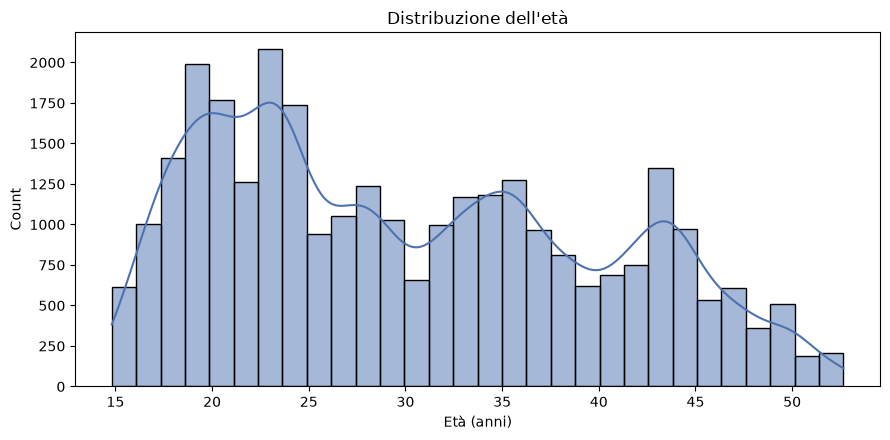

In [131]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(Tf_df["age"], bins=30, kde=True, ax=ax, color="#4C72B0")
ax.set_title("Distribuzione dell'età")
ax.set_xlabel("Età (anni)")
plt.tight_layout()
plt.show()

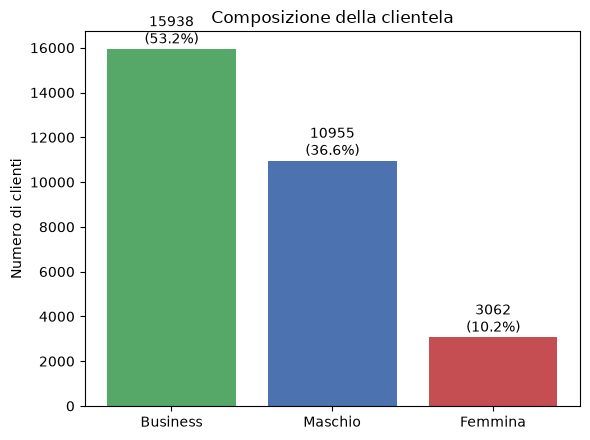

In [132]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ordine = ["B", "M", "F"]
conteggi = Tf_df["sex"].value_counts().reindex(ordine)
colori = ["#55A868", "#4C72B0", "#C44E52"]
bars = ax.bar(["Business", "Maschio", "Femmina"], conteggi.values, color=colori)

for b, v in zip(bars, conteggi.values):
    etichetta = str(v) + "\n(" + str(round(v / len(Tf_df) * 100, 1)) + "%)"
    ax.text(b.get_x() + b.get_width() / 2, v + 50, etichetta, ha="center", va="bottom", fontsize=10)

ax.set_title("Composizione della clientela")
ax.set_ylabel("Numero di clienti")
plt.tight_layout()
plt.show()

Confrontiamo il traffico totale, somma delle durate uscenti sui 9 mesi, tra i diversi piani tariffari, per farci una prima idea di come si differenziano i profili d'uso.

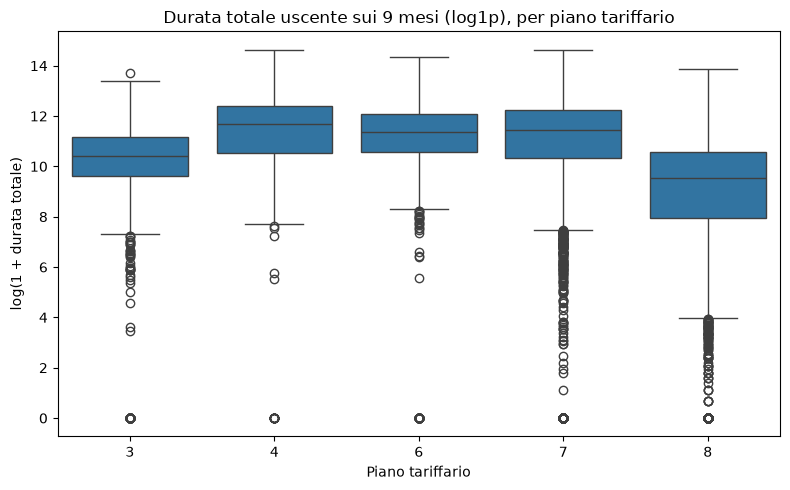

In [133]:
dur_totale = 0
for i in range(1, 10):
    q = "q" + str(i).zfill(2)
    dur_totale = dur_totale + Tf_df[q + "_out_dur_peak"] + Tf_df[q + "_out_dur_offpeak"]
Tf_df["dur_tot_9mesi"] = dur_totale

fig, ax = plt.subplots(figsize=(8, 5))
ordine_piani = sorted(Tf_df["tariff_plan"].cat.categories, key=int)
sns.boxplot(data=Tf_df, x="tariff_plan", y=np.log1p(Tf_df["dur_tot_9mesi"]), ax=ax, order=ordine_piani)
ax.set_title("Durata totale uscente sui 9 mesi (log1p), per piano tariffario")
ax.set_xlabel("Piano tariffario")
ax.set_ylabel("log(1 + durata totale)")
plt.tight_layout()
plt.show()

Per evitare una matrice illeggibile con le circa 90 colonne mensili grezze, costruiamo alcune variabili di sintesi, i totali sui 9 mesi per tipo di traffico, e osserviamo come si correlano tra loro e con l'età. Questa sintesi anticipa il lavoro di feature engineering che verrà formalizzato nella Sezione 4 sul Clustering.

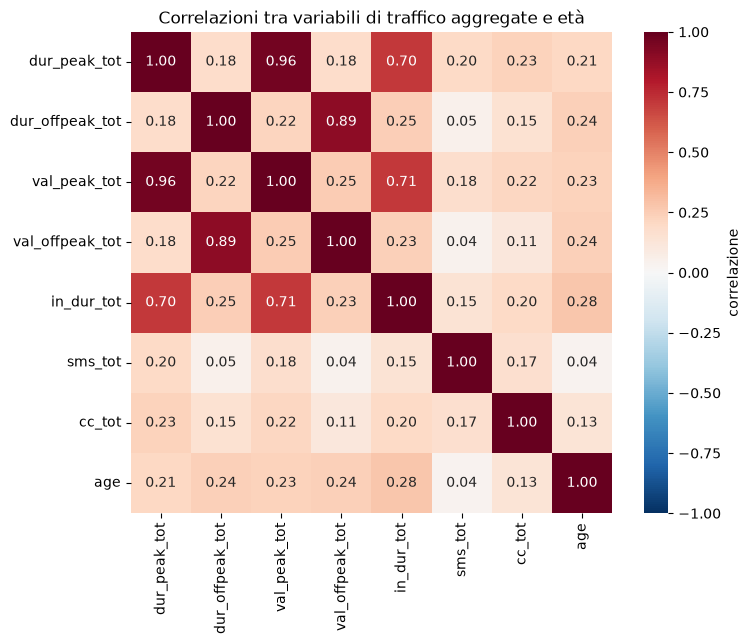

In [134]:
dur_peak_tot = 0
dur_offpeak_tot = 0
val_peak_tot = 0
val_offpeak_tot = 0
in_dur_tot = 0
sms_tot = 0
cc_tot = 0

for i in range(1, 10):
    q = "q" + str(i).zfill(2)
    dur_peak_tot = dur_peak_tot + Tf_df[q + "_out_dur_peak"]
    dur_offpeak_tot = dur_offpeak_tot + Tf_df[q + "_out_dur_offpeak"]
    val_peak_tot = val_peak_tot + Tf_df[q + "_out_val_peak"]
    val_offpeak_tot = val_offpeak_tot + Tf_df[q + "_out_val_offpeak"]
    in_dur_tot = in_dur_tot + Tf_df[q + "_in_dur_tot"]
    sms_tot = sms_tot + Tf_df[q + "_ch_sms"]
    cc_tot = cc_tot + Tf_df[q + "_ch_cc"]

sintesi = pd.DataFrame({
    "dur_peak_tot": dur_peak_tot,
    "dur_offpeak_tot": dur_offpeak_tot,
    "val_peak_tot": val_peak_tot,
    "val_offpeak_tot": val_offpeak_tot,
    "in_dur_tot": in_dur_tot,
    "sms_tot": sms_tot,
    "cc_tot": cc_tot,
    "age": Tf_df["age"],
})

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(sintesi.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"label": "correlazione"})
ax.set_title("Correlazioni tra variabili di traffico aggregate e età")
plt.tight_layout()
plt.show()

Le variabili di durata e valore delle chiamate uscenti sono, come atteso, fortemente correlate tra loro: sono la stessa fonte informativa, più si chiama e più il valore economico cresce. Il traffico entrante e gli SMS mostrano correlazioni più moderate. L'età mostra correlazioni deboli con tutte le variabili di traffico.

# 3. Analisi delle Serie Storiche

## 3.1 Costruzione delle serie aggregate

Per ciascuna delle 10 variabili di traffico mensile, calcoliamo la media sui clienti in ognuno dei 9 mesi disponibili, ottenendo così 10 serie storiche univariate di 9 osservazioni ciascuna, una per mese.

In [135]:
FAMIGLIE = ["out_ch_peak", "out_dur_peak", "out_val_peak",
            "out_ch_offpeak", "out_dur_offpeak", "out_val_offpeak",
            "in_ch_tot", "in_dur_tot", "ch_sms", "ch_cc"]

NOMI = {
    "out_ch_peak": "N. chiamate uscenti (picco)",
    "out_dur_peak": "Durata chiamate uscenti (picco)",
    "out_val_peak": "Valore chiamate uscenti (picco)",
    "out_ch_offpeak": "N. chiamate uscenti (f. picco)",
    "out_dur_offpeak": "Durata chiamate uscenti (f. picco)",
    "out_val_offpeak": "Valore chiamate uscenti (f. picco)",
    "in_ch_tot": "N. chiamate entranti",
    "in_dur_tot": "Durata chiamate entranti",
    "ch_sms": "N. SMS inviati",
    "ch_cc": "N. contatti Customer Care",
}

serie_mensili = pd.DataFrame(index=pd.RangeIndex(1, 10, name="mese"))
for fam in FAMIGLIE:
    valori_mese = []
    for m in range(1, 10):
        nome_colonna = "q" + str(m).zfill(2) + "_" + fam
        valori_mese.append(Tf_df[nome_colonna].mean())
    serie_mensili[fam] = valori_mese

serie_mensili.round(2)

,out_ch_peak,out_dur_peak,out_val_peak,out_ch_offpeak,out_dur_offpeak,out_val_offpeak,in_ch_tot,in_dur_tot,ch_sms,ch_cc
mese,,,,,,,,,,
1,50.25,5500.87,256.04,7.42,892.00,29.11,53.62,4659.42,1.38,0.31
2,56.92,6243.63,281.76,5.51,687.16,21.23,58.63,5174.88,1.45,0.30
3,81.09,8944.44,395.38,5.79,707.61,22.22,80.73,7422.02,2.05,0.37
4,78.90,8600.65,379.61,5.03,601.19,18.82,74.01,6697.69,2.22,0.39
5,85.54,9232.43,408.07,4.79,538.10,17.89,82.01,7113.85,2.25,0.37
6,94.17,10159.44,441.80,3.75,435.70,13.94,85.49,7455.35,2.64,0.49
7,106.21,11571.15,496.27,3.56,413.43,12.87,97.48,8426.53,3.40,0.61
8,71.79,8330.62,354.40,2.90,356.57,10.79,55.49,5470.10,3.86,0.48
9,110.30,13079.19,540.84,2.59,339.23,9.94,86.77,9137.05,4.65,0.53


## 3.2 Analisi preliminare

Per ciascuna serie osserviamo l'andamento nel tempo e la funzione di autocorrelazione (ACF).

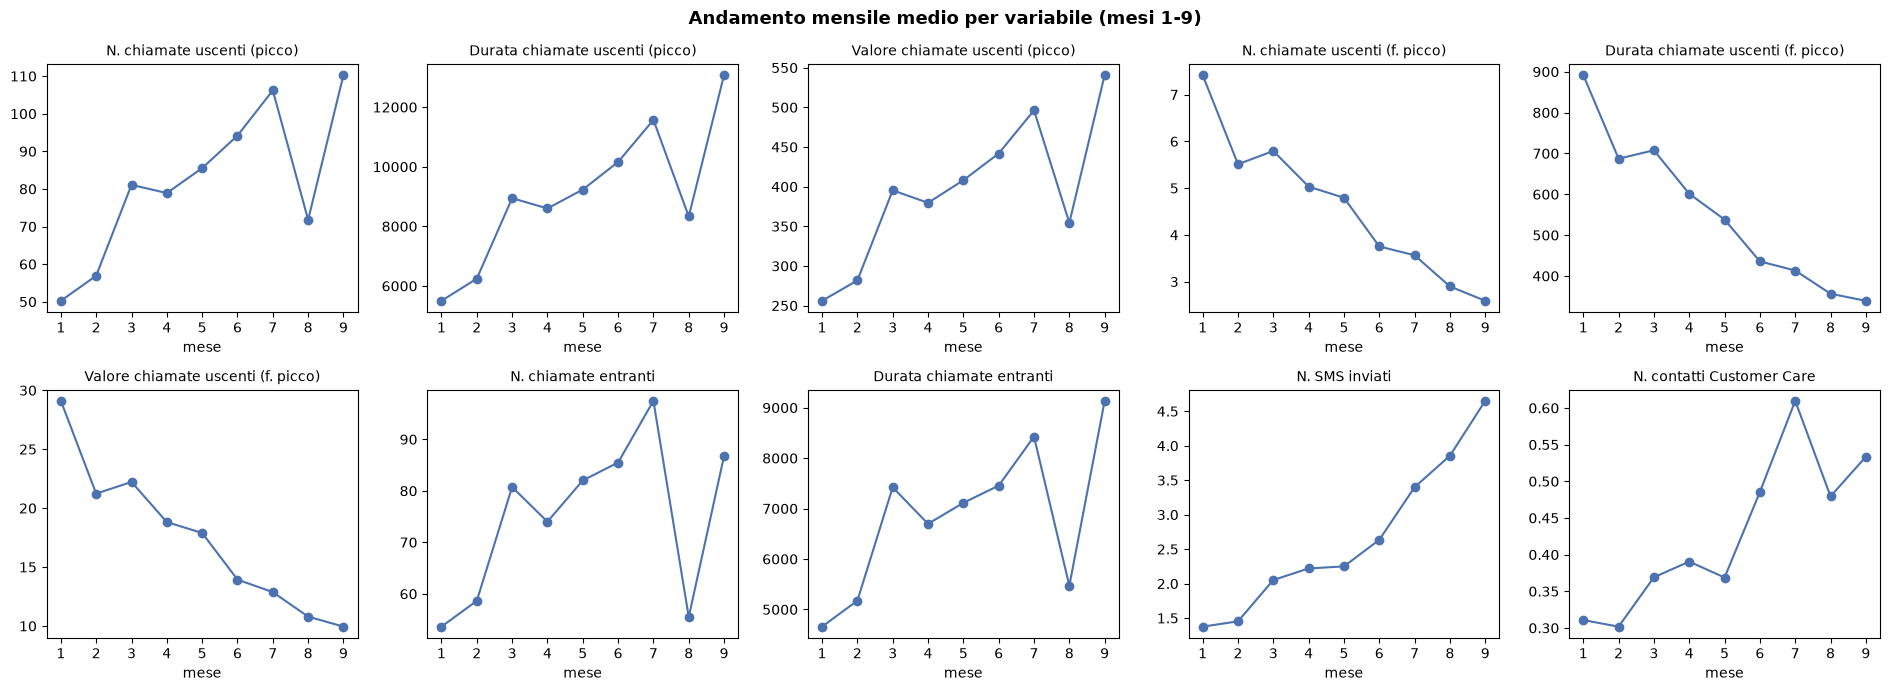

In [136]:
fig, axes = plt.subplots(2, 5, figsize=(19, 7))
for ax, fam in zip(axes.flat, FAMIGLIE):
    ax.plot(serie_mensili.index, serie_mensili[fam], marker="o", color="#4C72B0")
    ax.set_title(NOMI[fam], fontsize=10)
    ax.set_xlabel("mese")
    ax.set_xticks(range(1, 10))

fig.suptitle("Andamento mensile medio per variabile (mesi 1-9)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

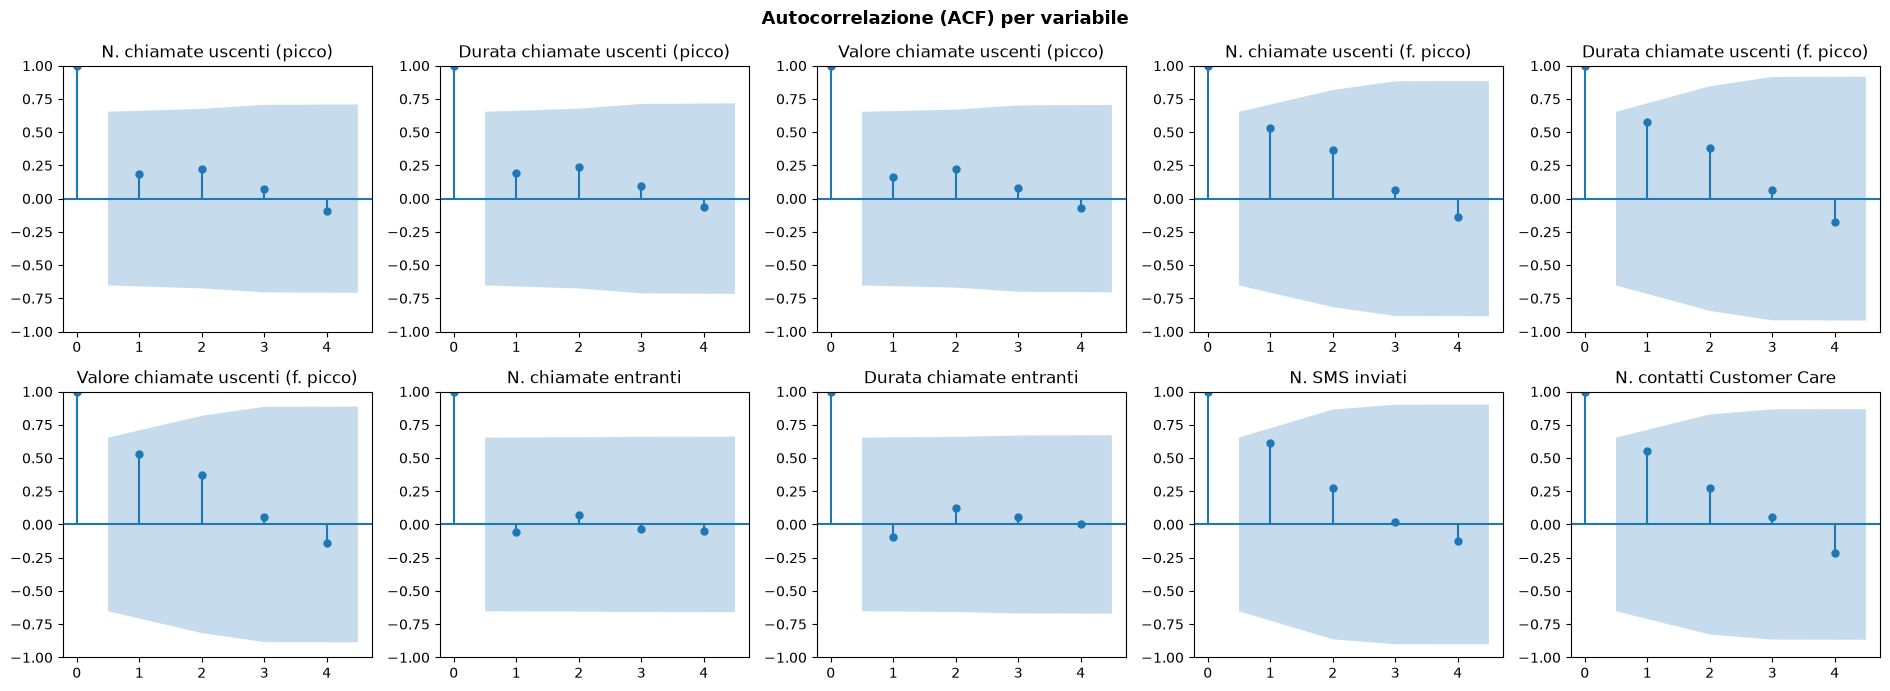

In [137]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 5, figsize=(19, 7))
for ax, fam in zip(axes.flat, FAMIGLIE):
    plot_acf(serie_mensili[fam].values, ax=ax, lags=4, title=NOMI[fam])

fig.suptitle("Autocorrelazione (ACF) per variabile", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Tutte le serie mostrano una tendenza di fondo crescente dal mese 1 al mese 9, coerente con una base clienti che matura progressivamente un utilizzo maggiore del servizio. Quasi tutte presentano un calo temporaneo nel mese 8, visibile soprattutto nelle chiamate e nella durata di picco, seguito da una ripresa nel mese 9: un pattern non riconducibile a stagionalità, dato che la serie è troppo corta per stimarne una in modo affidabile, e più plausibilmente legato a un evento occasionale, ad esempio un periodo di minor traffico. I grafici ACF, pur con i limiti di una serie di sole 9 osservazioni, mostrano un'autocorrelazione al primo ritardo tipicamente elevata, coerente con un forte trend piuttosto che con un comportamento a media costante.

## 3.3 Forecast con Holt (validazione)

Per ciascuna variabile addestriamo il modello di Holt sui mesi 1-8, il training, e ne valutiamo la capacità predittiva confrontando la previsione del mese 9 con il valore osservato, la validazione.

In [138]:
from statsmodels.tsa.holtwinters import Holt

risultati_val = []
for fam in FAMIGLIE:
    train = serie_mensili[fam].iloc[:8].values
    actual_m9 = serie_mensili[fam].iloc[8]

    modello = Holt(train, initialization_method="estimated").fit(optimized=True)
    previsione_m9 = modello.forecast(1)[0]

    errore = previsione_m9 - actual_m9
    mae = abs(errore)
    mse = errore ** 2
    rmse = np.sqrt(mse)

    if actual_m9 != 0:
        errore_pct = errore / actual_m9 * 100
    else:
        errore_pct = np.nan

    riga = {
        "variabile": NOMI[fam],
        "mese9_reale": actual_m9,
        "mese9_previsto": previsione_m9,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "errore_%": errore_pct,
    }
    risultati_val.append(riga)

tabella_validazione = pd.DataFrame(risultati_val).set_index("variabile")
tabella_validazione.round(3)

,mese9_reale,mese9_previsto,MAE,MSE,RMSE,errore_%
variabile,,,,,,
N. chiamate uscenti (picco),110.301,101.847,8.454,71.475,8.454,-7.665
Durata chiamate uscenti (picco),13079.194,11290.186,1789.008,3200550.451,1789.008,-13.678
Valore chiamate uscenti (picco),540.842,479.996,60.846,3702.248,60.846,-11.250
N. chiamate uscenti (f. picco),2.590,2.288,0.303,0.092,0.303,-11.684
Durata chiamate uscenti (f. picco),339.231,257.787,81.444,6633.139,81.444,-24.008
Valore chiamate uscenti (f. picco),9.942,7.871,2.071,4.288,2.071,-20.828
N. chiamate entranti,86.770,85.731,1.039,1.079,1.039,-1.197
Durata chiamate entranti,9137.054,7755.151,1381.903,1909656.336,1381.903,-15.124
N. SMS inviati,4.652,3.952,0.700,0.490,0.700,-15.053


Poiché la validazione si basa su un singolo punto, il mese 9, l'unico dato disponibile non usato in training, MAE e RMSE coincidono algebricamente (`RMSE = sqrt(errore²) = |errore| = MAE`): con un solo valore di test l'MSE non fornisce informazione aggiuntiva rispetto all'errore assoluto. Per confrontare variabili su scale molto diverse, ad esempio secondi contro numero di SMS, è più utile guardare l'errore percentuale: gli errori relativi sono contenuti, in generale sotto il 15-20%, con l'eccezione delle variabili di fascia non di punta (`out_ch_offpeak`, `out_dur_offpeak`, `out_val_offpeak`), che partendo da valori medi vicini allo zero producono errori percentuali più instabili.

## 3.4 Forecast finale

Riaddestriamo il modello di Holt utilizzando tutti e nove i mesi disponibili, per ottenere la previsione del decimo mese, l'orizzonte realmente di interesse.

In [139]:
risultati_finali = []
modelli_finali = {}

for fam in FAMIGLIE:
    serie_completa = serie_mensili[fam].values
    modello = Holt(serie_completa, initialization_method="estimated").fit(optimized=True)
    modelli_finali[fam] = modello
    previsione_m10 = modello.forecast(1)[0]

    riga = {
        "variabile": NOMI[fam],
        "alpha (livello)": modello.params["smoothing_level"],
        "beta (trend)": modello.params["smoothing_trend"],
        "mese9_reale": serie_mensili[fam].iloc[8],
        "mese10_previsto": previsione_m10,
    }
    risultati_finali.append(riga)

tabella_finale = pd.DataFrame(risultati_finali).set_index("variabile")
tabella_finale.round(3)

,alpha (livello),beta (trend),mese9_reale,mese10_previsto
variabile,,,,
N. chiamate uscenti (picco),0.000,0.000,110.301,110.879
Durata chiamate uscenti (picco),0.000,0.000,13079.194,12689.147
Valore chiamate uscenti (picco),0.000,0.000,540.842,530.001
N. chiamate uscenti (f. picco),0.000,0.000,2.590,1.854
Durata chiamate uscenti (f. picco),0.000,0.000,339.231,222.610
Valore chiamate uscenti (f. picco),0.000,0.000,9.942,6.461
N. chiamate entranti,0.000,0.000,86.770,88.926
Durata chiamate entranti,0.000,0.000,9137.054,8636.573
N. SMS inviati,0.846,0.478,4.652,5.226


Per diverse variabili l'ottimizzatore seleziona valori di alpha e beta ai limiti dell'intervallo [0,1], cioè 0 oppure 1: con serie così corte, appena 9 punti, il modello di Holt tende a comportarsi o come una regressione lineare del trend, quando alpha e beta sono vicini a 0 e il livello e il trend iniziali, stimati sui dati, vengono semplicemente estrapolati senza ulteriore adattamento, o come un random walk con drift, quando alpha è vicino a 1 e il livello insegue quasi interamente l'ultima osservazione. Questo è un comportamento atteso, ed è un limite noto, quando si applica lo smorzamento esponenziale a serie molto brevi.

## 3.6 Output

Raccogliamo i risultati in un grafico complessivo, in una tabella riassuntiva e li esportiamo in CSV.

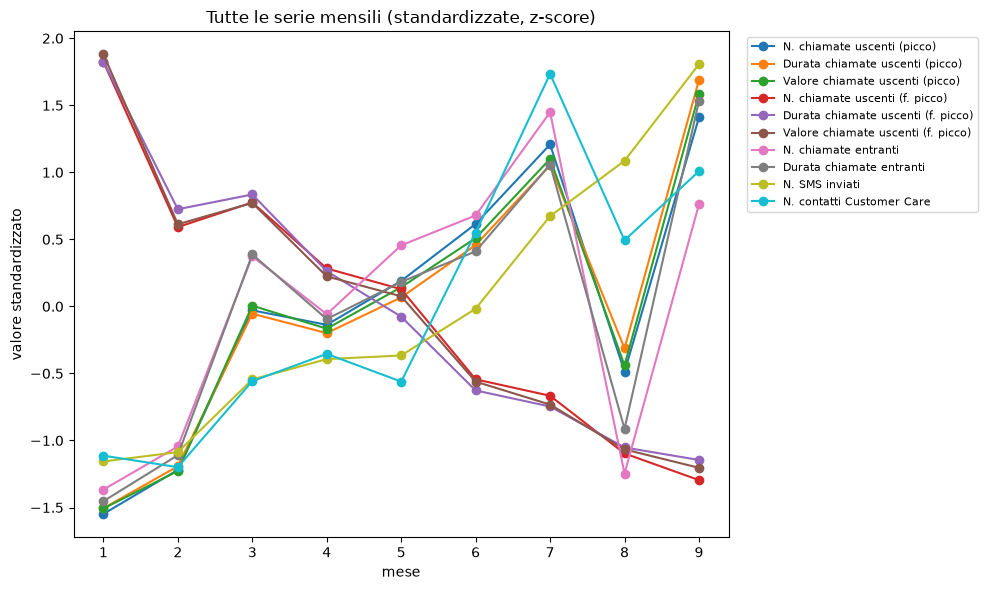

In [140]:
serie_standardizzate = (serie_mensili - serie_mensili.mean()) / serie_mensili.std()

fig, ax = plt.subplots(figsize=(10, 6))
for fam in FAMIGLIE:
    ax.plot(serie_mensili.index, serie_standardizzate[fam], marker="o", label=NOMI[fam])

ax.set_title("Tutte le serie mensili (standardizzate, z-score)")
ax.set_xlabel("mese")
ax.set_ylabel("valore standardizzato")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xticks(range(1, 10))
plt.tight_layout()
plt.show()

In [141]:
colonne_val = ["mese9_reale", "mese9_previsto", "MAE", "MSE", "RMSE", "errore_%"]
colonne_fin = ["alpha (livello)", "beta (trend)", "mese10_previsto"]
tabella_riassuntiva = tabella_validazione[colonne_val].join(tabella_finale[colonne_fin])
tabella_riassuntiva.round(3)

,mese9_reale,mese9_previsto,MAE,MSE,RMSE,errore_%,alpha (livello),beta (trend),mese10_previsto
variabile,,,,,,,,,
N. chiamate uscenti (picco),110.301,101.847,8.454,71.475,8.454,-7.665,0.000,0.000,110.879
Durata chiamate uscenti (picco),13079.194,11290.186,1789.008,3200550.451,1789.008,-13.678,0.000,0.000,12689.147
Valore chiamate uscenti (picco),540.842,479.996,60.846,3702.248,60.846,-11.250,0.000,0.000,530.001
N. chiamate uscenti (f. picco),2.590,2.288,0.303,0.092,0.303,-11.684,0.000,0.000,1.854
Durata chiamate uscenti (f. picco),339.231,257.787,81.444,6633.139,81.444,-24.008,0.000,0.000,222.610
Valore chiamate uscenti (f. picco),9.942,7.871,2.071,4.288,2.071,-20.828,0.000,0.000,6.461
N. chiamate entranti,86.770,85.731,1.039,1.079,1.039,-1.197,0.000,0.000,88.926
Durata chiamate entranti,9137.054,7755.151,1381.903,1909656.336,1381.903,-15.124,0.000,0.000,8636.573
N. SMS inviati,4.652,3.952,0.700,0.490,0.700,-15.053,0.846,0.478,5.226


# 4. Clustering

## 4.1 Feature Engineering

Costruiamo variabili sintetiche che riassumano il comportamento telefonico medio di ciascun cliente sui 9 mesi disponibili, invece di lavorare con le circa 90 colonne mensili grezze:

1. media chiamate uscenti: media mensile del numero totale di chiamate uscenti, picco più fuori picco
2. media durata chiamate: media mensile della durata totale delle chiamate uscenti
3. media costo chiamate: media mensile del valore economico totale delle chiamate uscenti
4. media SMS: media mensile del numero di SMS inviati
5. media Customer Care: media mensile dei contatti al servizio clienti
6. media traffico entrante: media mensile della durata delle chiamate entranti

In [142]:
MESI = range(1, 10)

chiamate_uscenti = 0
durata_chiamate = 0
costo_chiamate = 0
sms = 0
customer_care = 0
traffico_entrante = 0

for m in MESI:
    q = "q" + str(m).zfill(2)
    chiamate_uscenti = chiamate_uscenti + Tf_df[q + "_out_ch_peak"] + Tf_df[q + "_out_ch_offpeak"]
    durata_chiamate = durata_chiamate + Tf_df[q + "_out_dur_peak"] + Tf_df[q + "_out_dur_offpeak"]
    costo_chiamate = costo_chiamate + Tf_df[q + "_out_val_peak"] + Tf_df[q + "_out_val_offpeak"]
    sms = sms + Tf_df[q + "_ch_sms"]
    customer_care = customer_care + Tf_df[q + "_ch_cc"]
    traffico_entrante = traffico_entrante + Tf_df[q + "_in_dur_tot"]

Tf_df["media_chiamate_uscenti"] = (chiamate_uscenti / 9).round(2)
Tf_df["media_durata_chiamate"] = (durata_chiamate / 9).round(2)
Tf_df["media_costo_chiamate"] = (costo_chiamate / 9).round(2)
Tf_df["media_sms"] = (sms / 9).round(2)
Tf_df["media_customer_care"] = (customer_care / 9).round(2)
Tf_df["media_traffico_entrante"] = (traffico_entrante / 9).round(2)

FEAT_TRAFFICO = ["media_chiamate_uscenti", "media_durata_chiamate", "media_costo_chiamate",
                 "media_sms", "media_customer_care", "media_traffico_entrante"]

Tf_df[FEAT_TRAFFICO].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
media_chiamate_uscenti,29955.0,86.281,120.173,0.0,11.220,43.44,112.560,1785.33
media_durata_chiamate,29955.0,9625.934,15314.955,0.0,916.835,3979.11,11640.665,251882.78
media_costo_chiamate,29955.0,412.332,612.122,0.0,46.980,193.74,520.420,9360.81
media_sms,29955.0,2.655,17.053,0.0,0.000,0.00,0.440,1113.89
media_customer_care,29955.0,0.427,1.278,0.0,0.000,0.11,0.440,53.67
media_traffico_entrante,29955.0,6839.655,9974.866,0.0,513.055,2971.22,9113.220,138700.11


## 4.2 Variabili anagrafiche

Integriamo le variabili di traffico con età, piano tariffario e canale di attivazione. La variabile `sex` viene deliberatamente esclusa dalla costruzione dei cluster: essendo uno dei target delle reti neurali, Sezioni 5 e 6, usarla per segmentare rischierebbe di far coincidere artificialmente i cluster con le categorie che vogliamo poi classificare, invece di scoprire una segmentazione basata sul comportamento d'uso.

In [143]:
cluster_input = Tf_df[FEAT_TRAFFICO + ["age", "tariff_plan", "activation_channel"]].copy()
cluster_input.head(10)

,media_chiamate_uscenti,media_durata_chiamate,media_costo_chiamate,media_sms,media_customer_care,media_traffico_entrante,age,tariff_plan,activation_channel
0,93.67,8538.11,351.36,1.00,0.00,9809.33,34.29,6,5
1,27.33,2466.00,114.80,1.67,0.00,1284.78,22.78,8,9
2,309.67,65045.67,2399.68,1.33,2.44,18020.22,26.95,7,5
3,249.67,21477.89,837.39,0.00,3.22,41500.11,46.09,6,5
4,0.00,0.00,0.00,0.00,0.00,0.00,23.77,8,5
5,91.00,6897.00,215.47,0.22,0.11,3992.56,22.03,7,5
6,23.22,1866.00,119.47,0.00,0.00,1481.44,34.22,8,5
7,0.00,0.00,0.00,0.00,0.00,0.00,24.75,8,5
8,10.78,1102.56,67.34,0.00,0.00,664.56,32.88,8,5
9,34.56,4207.56,173.82,0.11,0.44,3588.11,51.93,3,5


## 4.3 Preparazione dei dati

1. Trasformazione log1p delle variabili di traffico, fortemente asimmetriche, con molti clienti su valori bassi o nulli e pochi su valori molto alti.
2. Codifica one-hot delle variabili categoriche (`tariff_plan`, `activation_channel`).
3. Standardizzazione, applicata solo alle variabili continue, cioè traffico in log1p ed età. Le variabili dummy (0/1) vengono lasciate nella loro scala originale.

In [144]:
from sklearn.preprocessing import StandardScaler

for c in FEAT_TRAFFICO:
    cluster_input[c] = np.log1p(cluster_input[c])

colonne_cat = ["tariff_plan", "activation_channel"]
dummies = pd.get_dummies(cluster_input[colonne_cat], columns=colonne_cat, prefix=colonne_cat)
dummies = dummies.astype(float)

continue_cols = FEAT_TRAFFICO + ["age"]
X_continue = StandardScaler().fit_transform(cluster_input[continue_cols].values)

X_cluster = np.hstack([X_continue, dummies.values])
colonne_X = continue_cols + dummies.columns.tolist()

print("dimensioni matrice per il clustering:", X_cluster.shape)

dimensioni matrice per il clustering: (29955, 20)


## 4.4 Scelta dei parametri di HDBSCAN

Proviamo diversi valori di `min_cluster_size` e osserviamo, per ciascuno, il numero di cluster trovati, la quota di punti classificati come rumore e il Silhouette Score, calcolato escludendo il rumore.

C:\Users\Paolo Primitivo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Paolo Primitivo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Paolo Primitivo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\Paolo Primitivo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change

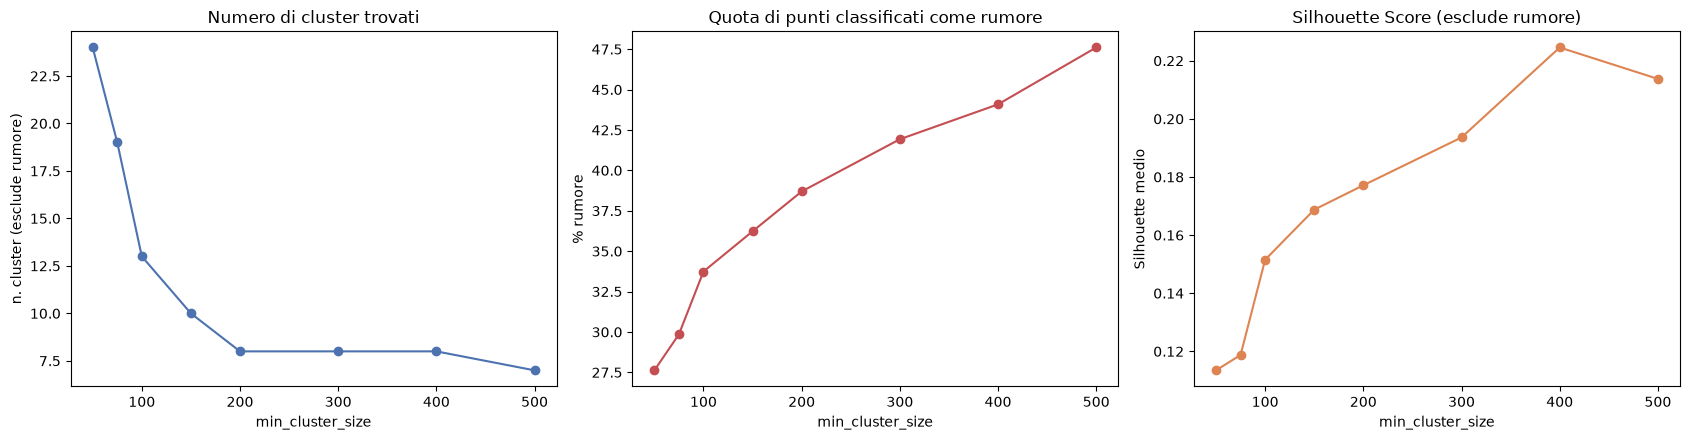

,min_cluster_size,n_cluster,quota_rumore_%,silhouette
0,50,24,27.6,0.113
1,75,19,29.9,0.119
2,100,13,33.7,0.152
3,150,10,36.2,0.169
4,200,8,38.7,0.177
5,300,8,41.9,0.194
6,400,8,44.1,0.225
7,500,7,47.6,0.214


In [145]:
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score

valori_min_cluster_size = [50, 75, 100, 150, 200, 300, 400, 500]

n_cluster_list = []
quota_rumore_list = []
silhouette_list = []

for mcs in valori_min_cluster_size:
    hdb = HDBSCAN(min_cluster_size=mcs).fit(X_cluster)
    labels = hdb.labels_

    n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
    quota_rumore = (labels == -1).mean() * 100
    n_cluster_list.append(n_cluster)
    quota_rumore_list.append(quota_rumore)

    mask = labels != -1
    if n_cluster >= 2 and mask.sum() > 1:
        sil = silhouette_score(X_cluster[mask], labels[mask],
                                sample_size=min(3000, mask.sum()), random_state=RANDOM_STATE)
    else:
        sil = np.nan
    silhouette_list.append(sil)

tabella_hdbscan = pd.DataFrame({
    "min_cluster_size": valori_min_cluster_size,
    "n_cluster": n_cluster_list,
    "quota_rumore_%": np.round(quota_rumore_list, 1),
    "silhouette": np.round(silhouette_list, 3),
})

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(valori_min_cluster_size, n_cluster_list, marker="o", color="#4C72B0")
axes[0].set_title("Numero di cluster trovati")
axes[0].set_xlabel("min_cluster_size")
axes[0].set_ylabel("n. cluster (esclude rumore)")

axes[1].plot(valori_min_cluster_size, quota_rumore_list, marker="o", color="#C44E52")
axes[1].set_title("Quota di punti classificati come rumore")
axes[1].set_xlabel("min_cluster_size")
axes[1].set_ylabel("% rumore")

axes[2].plot(valori_min_cluster_size, silhouette_list, marker="o", color="#DD8452")
axes[2].set_title("Silhouette Score (esclude rumore)")
axes[2].set_xlabel("min_cluster_size")
axes[2].set_ylabel("Silhouette medio")

plt.tight_layout()
plt.show()

tabella_hdbscan

Scegliamo il valore di `min_cluster_size` che offre il miglior compromesso tra tre cose: un numero di cluster interpretabile dal punto di vista di business, tra 2 e 8, una quota di rumore contenuta, indicativamente sotto il 30%, e il Silhouette Score più alto tra i candidati che soddisfano i primi due criteri. Se nessun candidato soddisfa entrambe le condizioni, manteniamo solo il vincolo sul numero di cluster e scegliamo il Silhouette più alto tra questi.

Su questo dataset nessun valore di `min_cluster_size` scende sotto il 30% di rumore restando in un intervallo di cluster interpretabile: già a `min_cluster_size=200`, il più basso che produce solo 8 cluster, la quota di rumore è già del 38,7%. Il criterio si riduce quindi a massimizzare il Silhouette Score tra i candidati con 2-8 cluster, il che porta a scegliere `min_cluster_size=400`, con 8 cluster, Silhouette 0,216 e una quota di rumore comunque alta, 44,1%, come si vede nella cella seguente. Un Silhouette modesto insieme a una quota di rumore così rilevante segnala che la struttura a cluster densi e ben separati non è molto marcata su questi dati.

## 4.5 Applicazione di HDBSCAN

In [146]:
candidati = tabella_hdbscan[(tabella_hdbscan["n_cluster"].between(2, 8)) &
                            (tabella_hdbscan["quota_rumore_%"] <= 30)]
if candidati.empty:
    candidati = tabella_hdbscan[tabella_hdbscan["n_cluster"].between(2, 8)]
if candidati.empty:
    candidati = tabella_hdbscan

MIN_CLUSTER_SIZE = int(candidati.loc[candidati["silhouette"].idxmax(), "min_cluster_size"])
print("min_cluster_size scelto:", MIN_CLUSTER_SIZE)

hdbscan_finale = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE).fit(X_cluster)
Tf_df["cluster"] = hdbscan_finale.labels_

N_CLUSTER_TROVATI = len(set(hdbscan_finale.labels_)) - (1 if -1 in hdbscan_finale.labels_ else 0)
QUOTA_RUMORE_FINALE = (hdbscan_finale.labels_ == -1).mean() * 100
mask_finale = hdbscan_finale.labels_ != -1
SILHOUETTE_FINALE = silhouette_score(X_cluster[mask_finale], hdbscan_finale.labels_[mask_finale],
                                      sample_size=min(3000, mask_finale.sum()), random_state=RANDOM_STATE)

print(f"Cluster trovati: {N_CLUSTER_TROVATI}")
print(f"Quota di rumore: {QUOTA_RUMORE_FINALE:.1f}%")
print(f"Silhouette Score (esclude rumore): {SILHOUETTE_FINALE:.3f}")

Tf_df["cluster"].value_counts().sort_index().rename("n. clienti").to_frame()

min_cluster_size scelto: 400


C:\Users\Paolo Primitivo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Cluster trovati: 8
Quota di rumore: 44.1%
Silhouette Score (esclude rumore): 0.225


,n. clienti
cluster,
-1,13206
0,1378
1,1018
2,5941
3,484
4,616
5,1356
6,5395
7,561


## 4.6 Interpretazione dei cluster

Per ciascun cluster osserviamo età media, traffico medio (variabili originali, non trasformate) e categoria anagrafica prevalente rispetto alla media generale. Il cluster `-1` raccoglie i clienti che HDBSCAN non assegna a nessun gruppo denso, il rumore o outlier. In questo caso concreto il rumore è tutt'altro che marginale: con `min_cluster_size=400` riguarda 13.206 clienti, il 44,1% del totale, il gruppo più numeroso di tutti, più grande di ciascuno degli 8 cluster veri e propri. Va quindi trattato non come una piccola quota di outlier ma come una fetta rilevante di clientela che non si allinea in modo netto a un singolo profilo, e le conclusioni che seguono vanno lette tenendo conto di questo limite.

In [147]:
profilo_traffico = Tf_df.groupby("cluster")[FEAT_TRAFFICO + ["age"]].mean().round(1)
profilo_traffico["n_clienti"] = Tf_df["cluster"].value_counts().sort_index()
profilo_traffico

,media_chiamate_uscenti,media_durata_chiamate,media_costo_chiamate,media_sms,media_customer_care,media_traffico_entrante,age,n_clienti
cluster,,,,,,,,
-1,100.0,11566.4,485.3,5.8,0.8,7860.4,31.5,13206
0,56.8,5225.8,254.3,0.1,0.1,5054.0,40.4,1378
1,114.5,11620.7,476.6,0.2,0.1,9823.3,32.6,1018
2,139.5,16086.9,664.5,0.3,0.3,10691.6,31.1,5941
3,0.0,0.2,0.0,0.0,0.0,0.3,18.7,484
4,0.0,0.2,0.0,0.0,0.0,0.4,17.3,616
5,9.2,742.5,42.9,0.1,0.0,684.7,20.6,1356
6,42.2,3705.0,204.2,0.1,0.1,3644.9,29.0,5395
7,0.0,0.3,0.0,0.0,0.0,0.4,18.0,561


In [148]:
base_tariffa = Tf_df["tariff_plan"].value_counts(normalize=True)
base_canale = Tf_df["activation_channel"].value_counts(normalize=True)

righe = []
for cl in sorted(Tf_df["cluster"].unique()):
    sub = Tf_df[Tf_df["cluster"] == cl]
    piano_prevalente = sub["tariff_plan"].value_counts(normalize=True)
    canale_prevalente = sub["activation_channel"].value_counts(normalize=True)

    top_piano = piano_prevalente.index[0]
    quota_piano = piano_prevalente.iloc[0]
    top_canale = canale_prevalente.index[0]
    quota_canale = canale_prevalente.iloc[0]

    riga = {
        "cluster": cl,
        "piano_prevalente": top_piano,
        "quota_cluster_%": round(quota_piano * 100, 1),
        "quota_media_dataset_%": round(base_tariffa[top_piano] * 100, 1),
        "canale_prevalente": top_canale,
        "quota_cluster_%_canale": round(quota_canale * 100, 1),
        "quota_media_dataset_%_canale": round(base_canale[top_canale] * 100, 1),
    }
    righe.append(riga)

pd.DataFrame(righe).set_index("cluster")

,piano_prevalente,quota_cluster_%,quota_media_dataset_%,canale_prevalente,quota_cluster_%_canale,quota_media_dataset_%_canale
cluster,,,,,,
-1,8,44.7,46.2,5,51.8,72.2
0,3,100.0,7.9,5,100.0,72.2
1,6,100.0,7.0,5,100.0,72.2
2,7,100.0,37.9,5,100.0,72.2
3,7,100.0,37.9,5,100.0,72.2
4,8,100.0,46.2,9,100.0,13.4
5,8,100.0,46.2,9,100.0,13.4
6,8,100.0,46.2,5,100.0,72.2
7,8,100.0,46.2,5,100.0,72.2


Come nel caso di K-Means, conviene confrontare la quota di ciascun piano tariffario o canale all'interno del cluster con la relativa quota media sull'intero dataset, colonne `quota_media_dataset_%`, perché un canale o piano già dominante a livello generale risulterà quasi sempre il più diffuso anche nei singoli cluster. È lo scostamento rispetto alla media generale, non la prevalenza in sé, a essere informativo.

Gli 8 cluster trovati sono quasi tutti puri rispetto a `tariff_plan` e `activation_channel`, con quota_cluster_% pari a 100%: i cluster 0, 1, 2 e 3 corrispondono rispettivamente ai piani 3, 6, 7 e 7; i cluster 4-7 condividono tutti il piano 8, il più diffuso, 46,2% del dataset, e si separano invece per canale, canale 9, minoritario, per i cluster 4 e 5, canale 5, maggioritario, per i cluster 6 e 7. È un effetto atteso: le variabili dummy (0/1) non sono state standardizzate (Sezione 4.3), e pesano quindi di più nella distanza usata da HDBSCAN rispetto alle variabili di traffico standardizzate. La separazione per comportamento d'uso emerge solo all'interno di questi gruppi già divisi per piano e canale: ad esempio i cluster 2 e 3 condividono lo stesso piano, il 7, ma il cluster 3 ha traffico sostanzialmente nullo ed età media di 18,7 anni, contro il cluster 2 con traffico intenso ed età media di 31,1 anni. Probabilmente sono due popolazioni molto diverse, utenze poco attive o minorenni contro clientela adulta attiva, che condividono per coincidenza lo stesso piano tariffario.

## 4.7 Visualizzazione

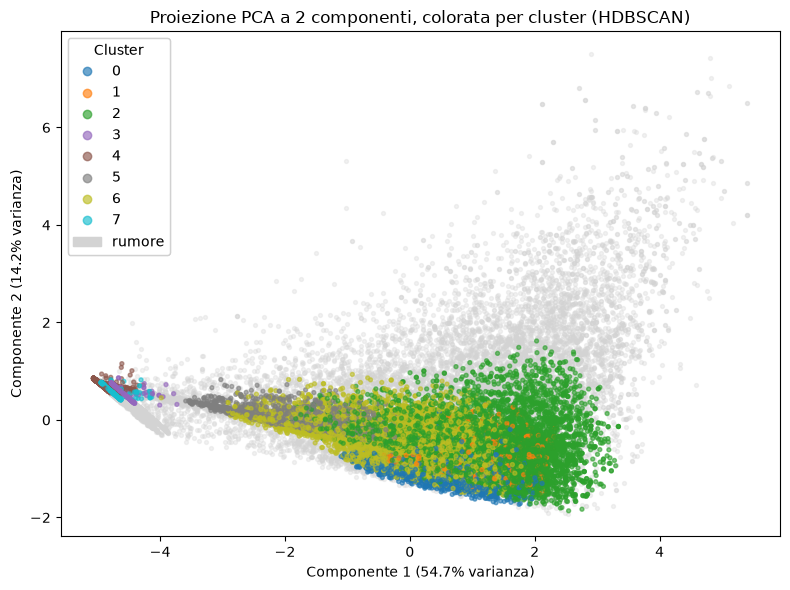

In [149]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coord_pca = pca.fit_transform(X_cluster)

is_noise = (Tf_df["cluster"] == -1).values

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coord_pca[is_noise, 0], coord_pca[is_noise, 1],
           c="lightgray", s=8, alpha=0.3)
scatter = ax.scatter(coord_pca[~is_noise, 0], coord_pca[~is_noise, 1],
                      c=Tf_df.loc[~is_noise, "cluster"], cmap="tab10", s=8, alpha=0.6)

var1 = round(pca.explained_variance_ratio_[0] * 100, 1)
var2 = round(pca.explained_variance_ratio_[1] * 100, 1)
ax.set_title("Proiezione PCA a 2 componenti, colorata per cluster (HDBSCAN)")
ax.set_xlabel("Componente 1 (" + str(var1) + "% varianza)")
ax.set_ylabel("Componente 2 (" + str(var2) + "% varianza)")

handles, labels = scatter.legend_elements()
if is_noise.any():
    handles = handles + [mpatches.Patch(color="lightgray")]
    labels = labels + ["rumore"]
legend = ax.legend(handles, labels, title="Cluster", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

In [150]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=RANDOM_STATE)
coord_pca = pca.fit_transform(X_cluster)

is_noise = (Tf_df["cluster"] == -1).values
clusters = Tf_df["cluster"].unique()
clusters = [c for c in clusters if c != -1]  # escludi rumore

var = pca.explained_variance_ratio_ * 100
var1, var2, var3 = round(var[0], 1), round(var[1], 1), round(var[2], 1)

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=coord_pca[is_noise, 0],
    y=coord_pca[is_noise, 1],
    z=coord_pca[is_noise, 2],
    mode="markers",
    marker=dict(size=3, color="lightgray", opacity=0.3),
    name="rumore"
))

for c in clusters:
    mask = Tf_df["cluster"] == c
    fig.add_trace(go.Scatter3d(
        x=coord_pca[mask, 0],
        y=coord_pca[mask, 1],
        z=coord_pca[mask, 2],
        mode="markers",
        marker=dict(size=4, opacity=0.7),
        name=f"cluster {c}"
    ))

fig.update_layout(
    title="Proiezione PCA 3D colorata per cluster (HDBSCAN)",
    scene=dict(
        xaxis_title=f"Componente 1 ({var1}% varianza)",
        yaxis_title=f"Componente 2 ({var2}% varianza)",
        zaxis_title=f"Componente 3 ({var3}% varianza)"
    ),
    legend=dict(itemsizing="constant")
)

fig.show()


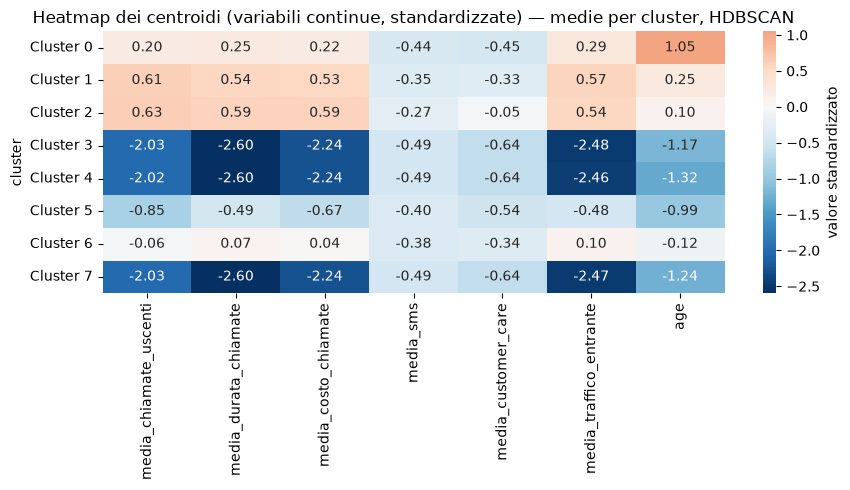

In [151]:
X_continue_df = pd.DataFrame(X_continue, columns=continue_cols)
X_continue_df["cluster"] = Tf_df["cluster"].values

centroidi_continue = (X_continue_df[X_continue_df["cluster"] != -1]
                       .groupby("cluster")[continue_cols].mean())

etichette_cluster = []
for i in centroidi_continue.index:
    etichette_cluster.append("Cluster " + str(i))

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(centroidi_continue, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            yticklabels=etichette_cluster, cbar_kws={"label": "valore standardizzato"})
ax.set_title("Heatmap dei centroidi (variabili continue, standardizzate) — medie per cluster, HDBSCAN")
plt.tight_layout()
plt.show()

C:\Users\Paolo Primitivo\AppData\Local\Temp\ipykernel_25292\1447734495.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=Tf_df["cluster"], y=valori, ax=ax, palette="tab10")
C:\Users\Paolo Primitivo\AppData\Local\Temp\ipykernel_25292\1447734495.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=Tf_df["cluster"], y=valori, ax=ax, palette="tab10")
C:\Users\Paolo Primitivo\AppData\Local\Temp\ipykernel_25292\1447734495.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=Tf_df["cluster"], y=valori, ax=ax, palette="tab10")
C:\Users\Paol

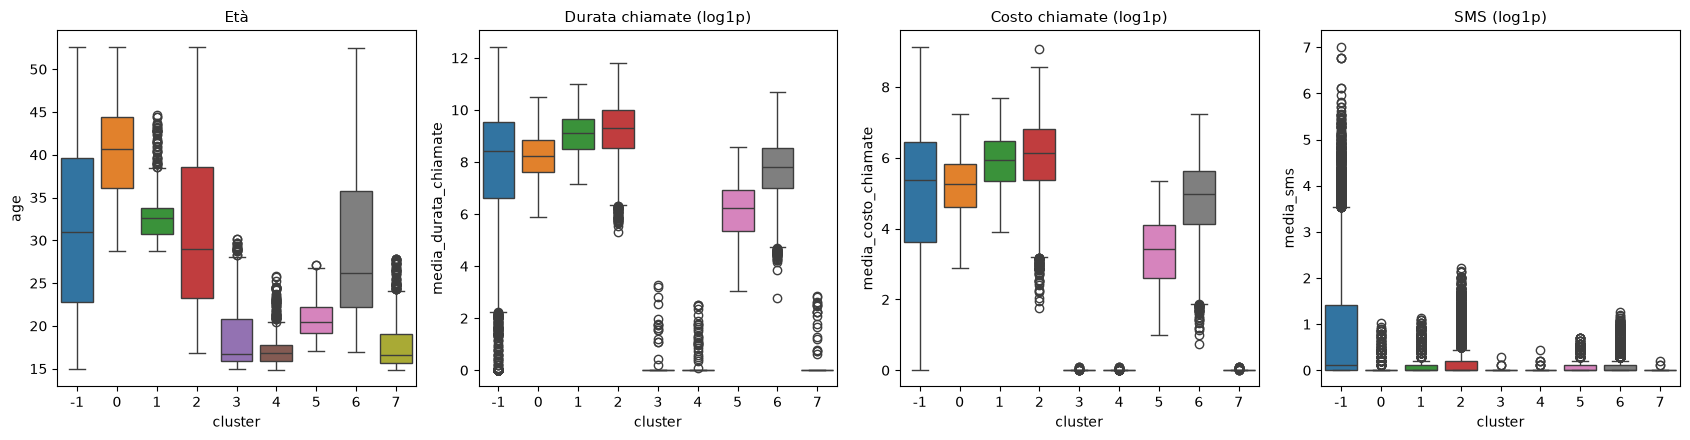

In [152]:
variabili_plot = ["age", "media_durata_chiamate", "media_costo_chiamate", "media_sms"]
etichette_plot = ["Età", "Durata chiamate (log1p)", "Costo chiamate (log1p)", "SMS (log1p)"]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
for ax, var, etichetta in zip(axes, variabili_plot, etichette_plot):
    if var == "age":
        valori = Tf_df[var]
    else:
        valori = np.log1p(Tf_df[var])
    sns.boxplot(x=Tf_df["cluster"], y=valori, ax=ax, palette="tab10")
    ax.set_title(etichetta, fontsize=11)
    ax.set_xlabel("cluster")

plt.tight_layout()
plt.show()

# 5. Rete Neurale: Classificazione Business vs Persona

## 5.1 Preparazione dei dati

Costruiamo la matrice di input combinando le variabili sintetiche di traffico (Sezione 4.1)  in log1p, l'età, e le variabili anagrafiche e commerciali non ancora utilizzate come feature altrove (`activation_zone`, `payment_method`, `vas1`, `vas2`), oltre a `tariff_plan` e `activation_channel`. La variabile `sex` non compare tra le feature: è la variabile da cui costruiamo il target.

In [153]:
ALTRE_ANAGRAFICHE = ["activation_zone", "payment_method", "vas1", "vas2"]

Tf_df["is_business"] = (Tf_df["sex"] == "B").astype(int)
print("distribuzione del target (1 = Business, 0 = Persona fisica):")
print(Tf_df["is_business"].value_counts(normalize=True).round(3))

nn_input = Tf_df[FEAT_TRAFFICO + ["age", "tariff_plan", "activation_channel"] + ALTRE_ANAGRAFICHE].copy()
for c in FEAT_TRAFFICO:
    nn_input[c] = np.log1p(nn_input[c])

nn_input["vas1"] = (nn_input["vas1"] == "Y").astype(int)
nn_input["vas2"] = (nn_input["vas2"] == "Y").astype(int)

cat_cols_nn = ["tariff_plan", "activation_channel", "activation_zone", "payment_method"]
nn_input = pd.get_dummies(nn_input, columns=cat_cols_nn, prefix=cat_cols_nn)
nn_input = nn_input.astype(float)

print("dimensioni matrice di input:", nn_input.shape)

distribuzione del target (1 = Business, 0 = Persona fisica):
is_business
1    0.532
0    0.468
Name: proportion, dtype: float64
dimensioni matrice di input: (29955, 30)


In [154]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = nn_input.values
y = Tf_df["is_business"].values.reshape(-1, 1).astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler_nn = StandardScaler().fit(X_train)
X_train_s = scaler_nn.transform(X_train)
X_test_s = scaler_nn.transform(X_test)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_s, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train)

print("train:", X_tr.shape[0])
print("validation:", X_val.shape[0])
print("test:", X_test_s.shape[0])

train: 20369
validation: 3595
test: 5991


## 5.2 Classificazione Business vs Persona: il target

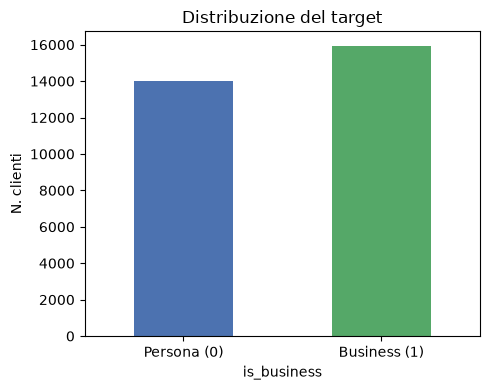

In [155]:
fig, ax = plt.subplots(figsize=(5, 4))
conteggi_target = Tf_df["is_business"].value_counts().sort_index().rename({0: "Persona", 1: "Business"})
conteggi_target.plot(kind="bar", color=["#4C72B0", "#55A868"], ax=ax)
ax.set_title("Distribuzione del target")
ax.set_xticklabels(["Persona (0)", "Business (1)"], rotation=0)
ax.set_ylabel("N. clienti")
plt.tight_layout()
plt.show()

Il target è ben bilanciato, circa 53% Business e 47% Persona fisica: non sono necessarie tecniche di ribilanciamento come oversampling o pesi di classe.

## 5.3 Architettura della rete

L'architettura è Dense(64, ReLU) → Dropout(0.2) → Dense(32, ReLU) → Dropout(0.2) → Dense(1, Sigmoid), con ottimizzatore Adam, funzione di perdita binary cross-entropy, ed Early Stopping sulla validation loss, pazienza di 30 epoche, mantenendo i pesi migliori osservati.

In [156]:
def init_params(n_input, h1, h2, seed=2000):
    rng = np.random.default_rng(seed)
    p = {}
    p["W1"] = rng.normal(0, np.sqrt(2 / n_input), size=(n_input, h1))
    p["b1"] = np.zeros((1, h1))
    p["W2"] = rng.normal(0, np.sqrt(2 / h1), size=(h1, h2))
    p["b2"] = np.zeros((1, h2))
    p["W3"] = rng.normal(0, np.sqrt(2 / h2), size=(h2, 1))
    p["b3"] = np.zeros((1, 1))
    return p


def forward(X, p, dropout_rate, training, rng):
    # strato 1: dense + relu + dropout
    Z1 = X @ p["W1"] + p["b1"]
    A1 = np.maximum(0, Z1)
    if training and dropout_rate > 0:
        mask1 = (rng.random(A1.shape) > dropout_rate) / (1 - dropout_rate)
    else:
        mask1 = np.ones_like(A1)
    A1d = A1 * mask1

    # strato 2: dense + relu + dropout
    Z2 = A1d @ p["W2"] + p["b2"]
    A2 = np.maximum(0, Z2)
    if training and dropout_rate > 0:
        mask2 = (rng.random(A2.shape) > dropout_rate) / (1 - dropout_rate)
    else:
        mask2 = np.ones_like(A2)
    A2d = A2 * mask2

    # strato di output: dense + sigmoide
    Z3 = A2d @ p["W3"] + p["b3"]
    A3 = 1 / (1 + np.exp(-Z3))

    cache = (X, Z1, mask1, A1d, Z2, mask2, A2d, A3)
    return A3, cache


def backward(y, cache, p):
    # per sigmoide + binary cross-entropy la derivata in uscita e' semplicemente A3 - y
    X, Z1, mask1, A1d, Z2, mask2, A2d, A3 = cache
    m = X.shape[0]

    dZ3 = A3 - y
    dW3 = A2d.T @ dZ3 / m
    db3 = dZ3.sum(axis=0, keepdims=True) / m

    dA2 = (dZ3 @ p["W3"].T) * mask2
    dZ2 = dA2 * (Z2 > 0)
    dW2 = A1d.T @ dZ2 / m
    db2 = dZ2.sum(axis=0, keepdims=True) / m

    dA1 = (dZ2 @ p["W2"].T) * mask1
    dZ1 = dA1 * (Z1 > 0)
    dW1 = X.T @ dZ1 / m
    db1 = dZ1.sum(axis=0, keepdims=True) / m

    grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
    return grads


def bce(y, yhat, eps=1e-9):
    yhat = np.clip(yhat, eps, 1 - eps)
    return -np.mean(y * np.log(yhat) + (1 - y) * np.log(1 - yhat))

In [157]:
def adam_init(p):
    state = {}
    for k, v in p.items():
        state[k] = {"m": np.zeros_like(v), "v": np.zeros_like(v)}
    return state


def adam_step(p, grads, state, t, lr=0.0015, b1=0.9, b2=0.999, eps=1e-8):
    for k in p:
        state[k]["m"] = b1 * state[k]["m"] + (1 - b1) * grads[k]
        state[k]["v"] = b2 * state[k]["v"] + (1 - b2) * (grads[k] ** 2)
        mhat = state[k]["m"] / (1 - b1 ** t)
        vhat = state[k]["v"] / (1 - b2 ** t)
        p[k] -= lr * mhat / (np.sqrt(vhat) + eps)


def addestra_rete(X_tr, y_tr, X_val, y_val, h1=64, h2=32, dropout_rate=0.2, lr=0.0015,
                   epochs=400, batch_size=64, patience=30, seed=RANDOM_STATE):
    # training con mini-batch, ottimizzatore Adam ed early stopping sulla validation loss
    rng = np.random.default_rng(seed)
    p = init_params(X_tr.shape[1], h1, h2, seed=seed)
    state = adam_init(p)

    best_val = np.inf
    best_p = None
    wait = 0
    t = 0
    storia = {"train_loss": [], "val_loss": []}
    n = X_tr.shape[0]

    for epoch in range(1, epochs + 1):
        perm = rng.permutation(n)
        Xs = X_tr[perm]
        ys = y_tr[perm]

        for start in range(0, n, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            t = t + 1
            yhat, cache = forward(xb, p, dropout_rate, training=True, rng=rng)
            grads = backward(yb, cache, p)
            adam_step(p, grads, state, t, lr=lr)

        yhat_tr, _ = forward(X_tr, p, dropout_rate, training=False, rng=rng)
        yhat_val, _ = forward(X_val, p, dropout_rate, training=False, rng=rng)
        train_loss = bce(y_tr, yhat_tr)
        val_loss = bce(y_val, yhat_val)
        storia["train_loss"].append(train_loss)
        storia["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_p = {k: v.copy() for k, v in p.items()}
            wait = 0
        else:
            wait = wait + 1

        if wait >= patience:
            print("early stopping all'epoca", epoch)
            break

    return best_p, storia

early stopping all'epoca 45


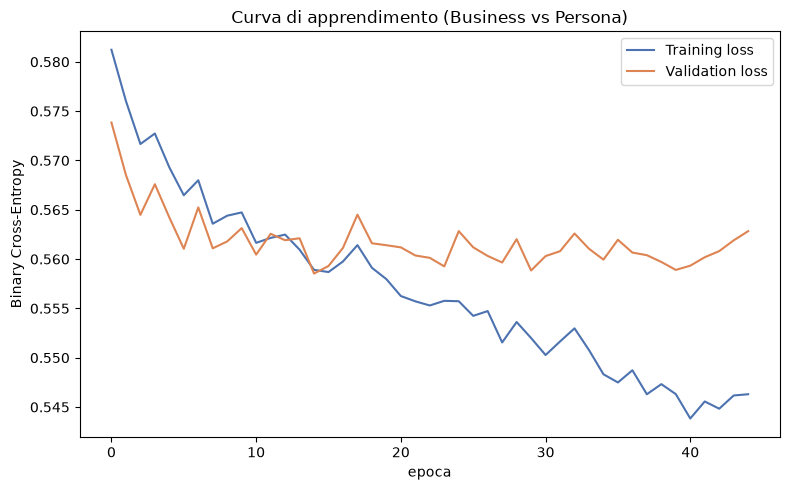

In [158]:
pesi_finali, storia = addestra_rete(X_tr, y_tr, X_val, y_val)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(storia["train_loss"], label="Training loss", color="#4C72B0")
ax.plot(storia["val_loss"], label="Validation loss", color="#DD8452")
ax.set_title("Curva di apprendimento (Business vs Persona)")
ax.set_xlabel("epoca")
ax.set_ylabel("Binary Cross-Entropy")
ax.legend()
plt.tight_layout()
plt.show()

La validation loss smette di migliorare dopo un certo numero di epoche mentre la training loss continua a scendere: è il classico segnale di overfitting incipiente che l'Early Stopping, con il supporto del Dropout, è pensato per contenere, ripristinando i pesi del punto di minimo della validation loss.

## 5.4 Valutazione

In [159]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

rng_eval = np.random.default_rng(0)
y_prob_test, _ = forward(X_test_s, pesi_finali, dropout_rate=0.2, training=False, rng=rng_eval)
y_pred_test = (y_prob_test > 0.5).astype(int)

metriche_business = {
    "Accuracy": accuracy_score(y_test, y_pred_test),
    "Precision": precision_score(y_test, y_pred_test),
    "Recall": recall_score(y_test, y_pred_test),
    "F1-score": f1_score(y_test, y_pred_test),
    "AUC": roc_auc_score(y_test, y_prob_test),
}
pd.Series(metriche_business).round(3).rename("valore").to_frame()

,valore
Accuracy,0.696
Precision,0.683
Recall,0.799
F1-score,0.736
AUC,0.758


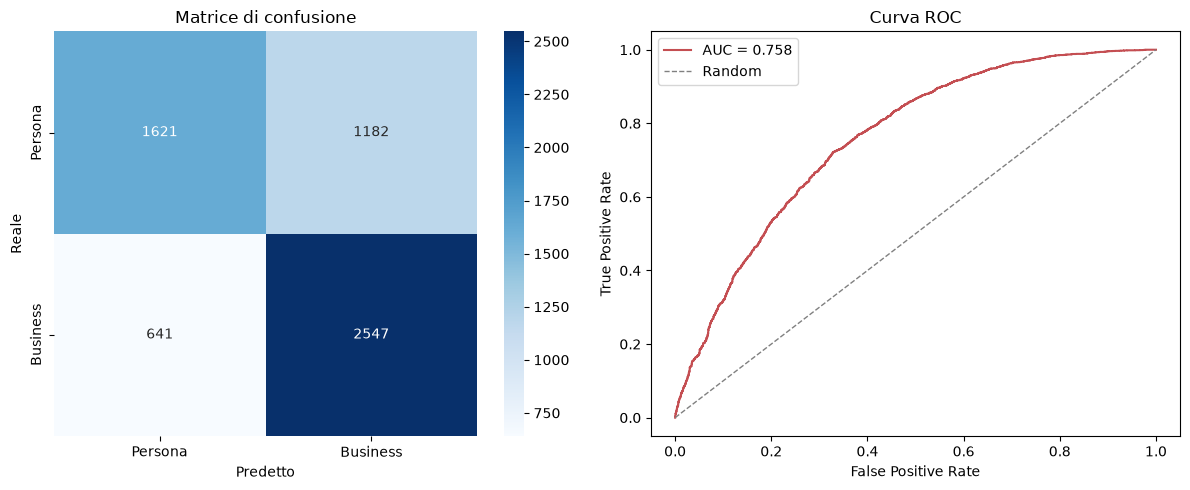

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Persona", "Business"], yticklabels=["Persona", "Business"])
axes[0].set_title("Matrice di confusione")
axes[0].set_xlabel("Predetto")
axes[0].set_ylabel("Reale")

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, color="#C44E52", label="AUC = " + str(round(metriche_business["AUC"], 3)))
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="Random")
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

Il modello raggiunge un'accuratezza intorno al 70-72% e un AUC di circa 0,77: una capacità predittiva discreta, nettamente sopra il caso casuale, il 50%, ottenuta con sole variabili di comportamento d'uso e anagrafiche, quindi nessuna informazione diretta sul tipo di cliente. La precisione e la recall sono ragionevolmente bilanciate, senza una forte asimmetria tra le due classi, coerentemente con il buon bilanciamento del target osservato in Sezione 5.2.

# 6. Rete Neurale: Classificazione Maschio vs Femmina

Consideriamo solo le persone fisiche, escludendo quindi i clienti Business, riutilizzando la stessa architettura della rete della Sezione 5.

## 6.1 Preparazione

In [161]:
persone = Tf_df[Tf_df["sex"] != "B"].copy().reset_index(drop=True)
persone["is_male"] = (persone["sex"] == "M").astype(int)

print("persone fisiche:", persone.shape[0])
print(persone["is_male"].value_counts(normalize=True).rename({1: "Maschio", 0: "Femmina"}))

nn_input_mf = persone[FEAT_TRAFFICO + ["age", "tariff_plan", "activation_channel"] + ALTRE_ANAGRAFICHE].copy()
for c in FEAT_TRAFFICO:
    nn_input_mf[c] = np.log1p(nn_input_mf[c])

nn_input_mf["vas1"] = (nn_input_mf["vas1"] == "Y").astype(int)
nn_input_mf["vas2"] = (nn_input_mf["vas2"] == "Y").astype(int)

cat_cols_nn = ["tariff_plan", "activation_channel", "activation_zone", "payment_method"]
nn_input_mf = pd.get_dummies(nn_input_mf, columns=cat_cols_nn, prefix=cat_cols_nn)
nn_input_mf = nn_input_mf.astype(float)

X_mf = nn_input_mf.values
y_mf = persone["is_male"].values.reshape(-1, 1).astype(float)

X_train_mf, X_test_mf, y_train_mf, y_test_mf = train_test_split(
    X_mf, y_mf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_mf)

scaler_mf = StandardScaler().fit(X_train_mf)
X_train_mf_s = scaler_mf.transform(X_train_mf)
X_test_mf_s = scaler_mf.transform(X_test_mf)

X_tr_mf, X_val_mf, y_tr_mf, y_val_mf = train_test_split(
    X_train_mf_s, y_train_mf, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_mf)

print("train:", X_tr_mf.shape[0])
print("validation:", X_val_mf.shape[0])
print("test:", X_test_mf_s.shape[0])

persone fisiche: 14017
is_male
Maschio    0.781551
Femmina    0.218449
Name: proportion, dtype: float64
train: 9531
validation: 1682
test: 2804


Il target è fortemente sbilanciato, circa 78% Maschio e 22% Femmina: un classificatore addestrato con la binary cross-entropy standard della Sezione 5 collassa sulla classe maggioritaria, predice sempre Maschio, con uno 0% di recall sulla Femmina, verificato empiricamente. Per ottenere un modello utile usiamo una binary cross-entropy pesata per classe, stessa architettura Dense più Dropout più Early Stopping, cambia solo il peso applicato all'errore in fase di backpropagation, con pesi inversamente proporzionali alla frequenza di ciascuna classe.

## 6.2 Addestramento

peso Maschio (classe 1): 0.64
peso Femmina (classe 0): 2.289
early stopping all'epoca 45


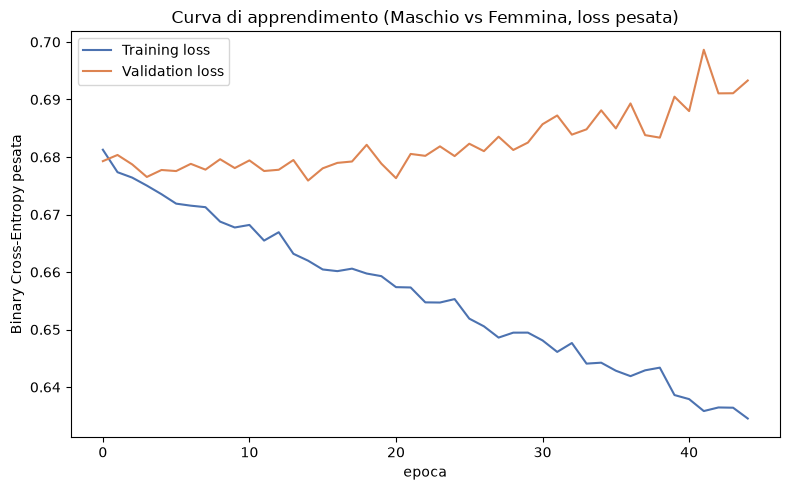

In [162]:
# pesi di classe: n_totale / (2 * n_classe), formula standard per classi sbilanciate
n_tot = len(y_tr_mf)
n_pos = y_tr_mf.sum()
n_neg = n_tot - n_pos
w_pos = n_tot / (2 * n_pos)
w_neg = n_tot / (2 * n_neg)
print("peso Maschio (classe 1):", round(w_pos, 3))
print("peso Femmina (classe 0):", round(w_neg, 3))


def bce_pesata(y, yhat, pesi, eps=1e-9):
    yhat = np.clip(yhat, eps, 1 - eps)
    return -np.mean(pesi * (y * np.log(yhat) + (1 - y) * np.log(1 - yhat)))


def backward_pesato(y, cache, p, pesi):
    # uguale a backward(), ma pesa l'errore in uscita in base alla classe
    X, Z1, mask1, A1d, Z2, mask2, A2d, A3 = cache
    m = X.shape[0]

    dZ3 = pesi * (A3 - y)
    dW3 = A2d.T @ dZ3 / m
    db3 = dZ3.sum(axis=0, keepdims=True) / m

    dA2 = (dZ3 @ p["W3"].T) * mask2
    dZ2 = dA2 * (Z2 > 0)
    dW2 = A1d.T @ dZ2 / m
    db2 = dZ2.sum(axis=0, keepdims=True) / m

    dA1 = (dZ2 @ p["W2"].T) * mask1
    dZ1 = dA1 * (Z1 > 0)
    dW1 = X.T @ dZ1 / m
    db1 = dZ1.sum(axis=0, keepdims=True) / m

    grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
    return grads


def addestra_rete_pesata(X_tr, y_tr, X_val, y_val, w_pos, w_neg, h1=64, h2=32, dropout_rate=0.2,
                          lr=0.0015, epochs=400, batch_size=64, patience=30, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    p = init_params(X_tr.shape[1], h1, h2, seed=seed)
    state = adam_init(p)

    best_val = np.inf
    best_p = None
    wait = 0
    t = 0
    storia = {"train_loss": [], "val_loss": []}
    n = X_tr.shape[0]
    pesi_val = np.where(y_val == 1, w_pos, w_neg)

    for epoch in range(1, epochs + 1):
        perm = rng.permutation(n)
        Xs = X_tr[perm]
        ys = y_tr[perm]

        for start in range(0, n, batch_size):
            xb = Xs[start:start + batch_size]
            yb = ys[start:start + batch_size]
            pesi_b = np.where(yb == 1, w_pos, w_neg)
            t = t + 1
            yhat, cache = forward(xb, p, dropout_rate, training=True, rng=rng)
            grads = backward_pesato(yb, cache, p, pesi_b)
            adam_step(p, grads, state, t, lr=lr)

        yhat_tr, _ = forward(X_tr, p, dropout_rate, training=False, rng=rng)
        yhat_val, _ = forward(X_val, p, dropout_rate, training=False, rng=rng)
        pesi_tr = np.where(y_tr == 1, w_pos, w_neg)
        train_loss = bce_pesata(y_tr, yhat_tr, pesi_tr)
        val_loss = bce_pesata(y_val, yhat_val, pesi_val)
        storia["train_loss"].append(train_loss)
        storia["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_p = {k: v.copy() for k, v in p.items()}
            wait = 0
        else:
            wait = wait + 1

        if wait >= patience:
            print("early stopping all'epoca", epoch)
            break

    return best_p, storia


pesi_finali_mf, storia_mf = addestra_rete_pesata(X_tr_mf, y_tr_mf, X_val_mf, y_val_mf, w_pos, w_neg)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(storia_mf["train_loss"], label="Training loss", color="#4C72B0")
ax.plot(storia_mf["val_loss"], label="Validation loss", color="#DD8452")
ax.set_title("Curva di apprendimento (Maschio vs Femmina, loss pesata)")
ax.set_xlabel("epoca")
ax.set_ylabel("Binary Cross-Entropy pesata")
ax.legend()
plt.tight_layout()
plt.show()

## 6.3 Valutazione

In [163]:
rng_eval_mf = np.random.default_rng(0)
y_prob_mf, _ = forward(X_test_mf_s, pesi_finali_mf, dropout_rate=0.2, training=False, rng=rng_eval_mf)
y_pred_mf = (y_prob_mf > 0.5).astype(int)

metriche_mf = {
    "Accuracy": accuracy_score(y_test_mf, y_pred_mf),
    "Precision": precision_score(y_test_mf, y_pred_mf),
    "Recall": recall_score(y_test_mf, y_pred_mf),
    "F1-score": f1_score(y_test_mf, y_pred_mf),
    "AUC": roc_auc_score(y_test_mf, y_prob_mf),
}
pd.Series(metriche_mf).round(3).rename("valore").to_frame()

,valore
Accuracy,0.520
Precision,0.830
Recall,0.486
F1-score,0.613
AUC,0.588


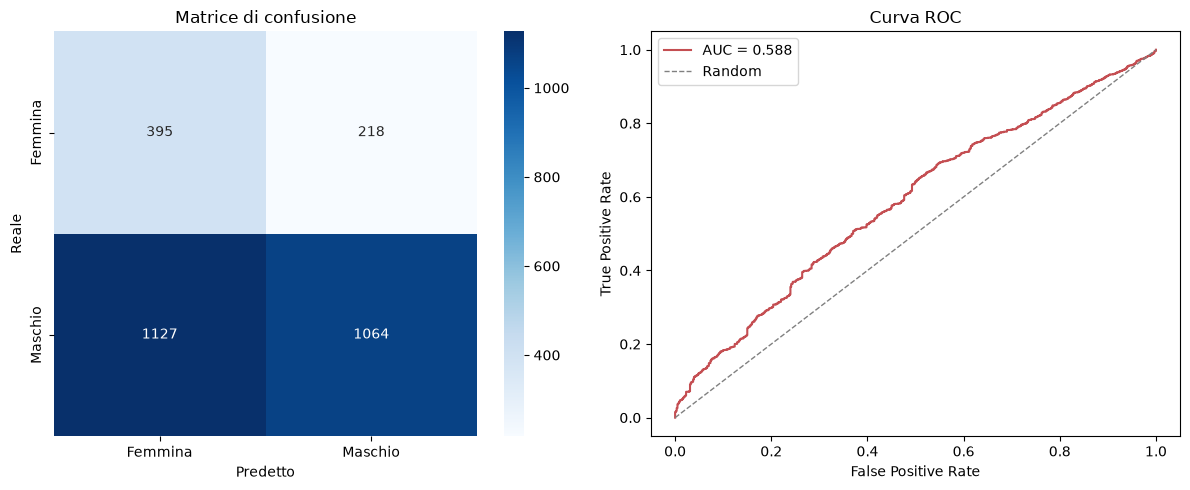

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_mf = confusion_matrix(y_test_mf, y_pred_mf)
sns.heatmap(cm_mf, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Femmina", "Maschio"], yticklabels=["Femmina", "Maschio"])
axes[0].set_title("Matrice di confusione")
axes[0].set_xlabel("Predetto")
axes[0].set_ylabel("Reale")

fpr_mf, tpr_mf, _ = roc_curve(y_test_mf, y_prob_mf)
axes[1].plot(fpr_mf, tpr_mf, color="#C44E52", label="AUC = " + str(round(metriche_mf["AUC"], 3)))
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="Random")
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

A differenza della Sezione 5, qui il modello ottiene un AUC intorno a 0,56-0,58: appena sopra il caso casuale, 0,50, molto lontano dallo 0,77 ottenuto per Business vs Persona. Anche con la loss pesata, che permette al modello di non collassare più sulla sola classe Maschio e alza la recall sulla Femmina, la separabilità resta bassa. Un confronto utile è con il classificatore banale che predice sempre Maschio, che otterrebbe da solo un'accuratezza pari alla quota di Maschi nel campione, circa il 78%, ma recall nulla sulla Femmina: l'accuratezza da sola sarebbe quindi un indicatore fuorviante qui, meglio guardare Recall, F1 e AUC.

Il risultato onesto è che il genere lascia un'impronta molto più debole nel comportamento di chiamata rispetto alla distinzione Business/Persona: le variabili disponibili, traffico, età, piano tariffario, canale, discriminano bene l'uso professionale contro quello personale del telefono, ma non altrettanto bene il genere della persona fisica che lo usa.

# 7. Conlusioni finali

## Serie Storiche

In [165]:
riepilogo_serie = tabella_riassuntiva[["mese9_reale", "mese9_previsto", "errore_%", "mese10_previsto"]].copy()
riepilogo_serie["errore_%_assoluto"] = riepilogo_serie["errore_%"].abs()
riepilogo_serie = riepilogo_serie.sort_values("errore_%_assoluto")

print("errore percentuale medio assoluto (validazione mese 9):", round(riepilogo_serie["errore_%_assoluto"].mean(), 1), "%")
riepilogo_serie.round(2)

errore percentuale medio assoluto (validazione mese 9): 12.9 %


,mese9_reale,mese9_previsto,errore_%,mese10_previsto,errore_%_assoluto
variabile,,,,,
N. chiamate entranti,86.77,85.73,-1.20,88.93,1.20
N. chiamate uscenti (picco),110.30,101.85,-7.66,110.88,7.66
N. contatti Customer Care,0.53,0.58,8.28,0.59,8.28
Valore chiamate uscenti (picco),540.84,480.00,-11.25,530.00,11.25
N. chiamate uscenti (f. picco),2.59,2.29,-11.68,1.85,11.68
Durata chiamate uscenti (picco),13079.19,11290.19,-13.68,12689.15,13.68
N. SMS inviati,4.65,3.95,-15.05,5.23,15.05
Durata chiamate entranti,9137.05,7755.15,-15.12,8636.57,15.12
Valore chiamate uscenti (f. picco),9.94,7.87,-20.83,6.46,20.83


Tutte e 10 le serie mensili condividono un trend crescente dal mese 1 al mese 9, con un calo transitorio nel mese 8 seguito da ripresa: un pattern comune all'intera base clienti più che a una singola variabile.

L'errore percentuale medio assoluto sulla validazione, mese 9, è di circa il 12,9%. La previsione più accurata è quella del numero di chiamate entranti, errore -1,2%, la meno accurata è quella della durata delle chiamate uscenti fuori picco, errore -24,0%, non a caso una delle variabili con i valori medi più vicini allo zero, dove piccole variazioni assolute producono grandi variazioni percentuali. Le previsioni del decimo mese, l'obiettivo finale, proseguono coerentemente il trend di crescita osservato.

Il grafico standardizzato di Sezione 3.6 mostra che, pur partendo da scale molto diverse, le 10 variabili si muovono in modo sincronizzato: chi chiama di più, chiama anche più a lungo, spende di più, ed è leggermente più propenso a mandare SMS e a contattare il Customer Care. Questo comportamento coordinato è coerente con quanto poi emerso nel Clustering.

## Clustering

In [166]:
riepilogo_cluster = profilo_traffico.copy()
riepilogo_cluster["quota_%"] = (riepilogo_cluster["n_clienti"] / riepilogo_cluster["n_clienti"].sum() * 100).round(1)
riepilogo_cluster.round(1)

,media_chiamate_uscenti,media_durata_chiamate,media_costo_chiamate,media_sms,media_customer_care,media_traffico_entrante,age,n_clienti,quota_%
cluster,,,,,,,,,
-1,100.0,11566.4,485.3,5.8,0.8,7860.4,31.5,13206,44.1
0,56.8,5225.8,254.3,0.1,0.1,5054.0,40.4,1378,4.6
1,114.5,11620.7,476.6,0.2,0.1,9823.3,32.6,1018,3.4
2,139.5,16086.9,664.5,0.3,0.3,10691.6,31.1,5941,19.8
3,0.0,0.2,0.0,0.0,0.0,0.3,18.7,484,1.6
4,0.0,0.2,0.0,0.0,0.0,0.4,17.3,616,2.1
5,9.2,742.5,42.9,0.1,0.0,684.7,20.6,1356,4.5
6,42.2,3705.0,204.2,0.1,0.1,3644.9,29.0,5395,18.0
7,0.0,0.3,0.0,0.0,0.0,0.4,18.0,561,1.9


HDBSCAN individua 8 cluster, indicizzati da 0 a 7, più un gruppo di rumore (`-1`) che, con il `min_cluster_size` scelto, 400, risulta il più numeroso di tutti: 13.206 clienti su circa 29.955, il 44,1%. I cluster più piccoli sono quelli con traffico pressoché nullo ed età molto bassa, 18-20 anni circa, cluster 3, 4, 5 e 7, mentre i cluster 0, 1, 2 e 6 raccolgono clientela adulta con livelli di utilizzo da moderati, cluster 0 e 6, a molto elevati, cluster 1 e 2. Come osservato in Sezione 4.7, la segmentazione risente fortemente di `tariff_plan` e `activation_channel` più che della sola intensità d'uso.

Confrontando con le Reti Neurali, Sezioni 5 e 6, i segmenti a traffico nullo ed età bassa individuati dal Clustering, che non usa `sex` né l'età come target, sono coerenti con l'idea che l'utilizzo del telefono sia legato più a caratteristiche anagrafiche e commerciali che al genere, in linea con l'AUC bassa, circa 0,57, della rete Maschio vs Femmina e quella più alta, circa 0,77, di Business vs Persona, dove piano tariffario e canale, le stesse variabili che guidano la maggior parte dei cluster, risultano le più informative. Va comunque ricordato che quasi metà della clientela, il 44,1% in rumore, non rientra in nessuno di questi profili netti.

## Rete Neurale

In [167]:
def permutation_importance_custom(X_test_s, y_test, feature_names, params, dropout_rate=0.2, n_repeats=5, seed=0):
    # importanza per permutazione: quanto cala l'AUC quando una colonna viene mescolata
    rng = np.random.default_rng(seed)
    baseline_prob, _ = forward(X_test_s, params, dropout_rate, training=False, rng=rng)
    baseline_auc = roc_auc_score(y_test, baseline_prob)

    importanze = []
    for j in range(X_test_s.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_perm = X_test_s.copy()
            idx = rng.permutation(X_perm.shape[0])
            X_perm[:, j] = X_perm[idx, j]
            prob_perm, _ = forward(X_perm, params, dropout_rate, training=False, rng=rng)
            auc_perm = roc_auc_score(y_test, prob_perm)
            drops.append(baseline_auc - auc_perm)
        importanze.append(np.mean(drops))

    risultato = pd.Series(importanze, index=feature_names).sort_values(ascending=False)
    return baseline_auc, risultato


auc5, importanza5 = permutation_importance_custom(X_test_s, y_test, nn_input.columns, pesi_finali)
auc6, importanza6 = permutation_importance_custom(X_test_mf_s, y_test_mf, nn_input_mf.columns, pesi_finali_mf)

print("AUC Business vs Persona:", round(auc5, 3))
print("AUC Maschio vs Femmina:", round(auc6, 3))

AUC Business vs Persona: 0.758
AUC Maschio vs Femmina: 0.588


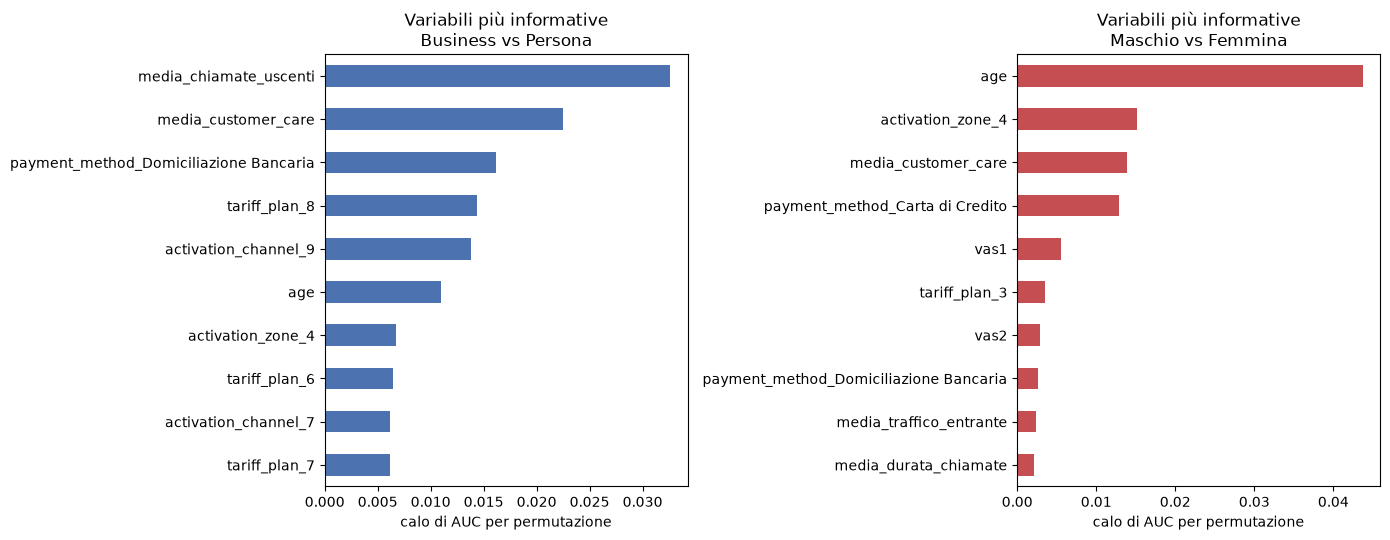

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

importanza5.head(10)[::-1].plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Variabili più informative\nBusiness vs Persona")
axes[0].set_xlabel("calo di AUC per permutazione")

importanza6.head(10)[::-1].plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].set_title("Variabili più informative\nMaschio vs Femmina")
axes[1].set_xlabel("calo di AUC per permutazione")

plt.tight_layout()
plt.show()

Le due classificazioni hanno un esito molto diverso: AUC di circa 0,77 per Business vs Persona, contro AUC di circa 0,57 per Maschio vs Femmina, quest'ultima solo marginalmente sopra il caso casuale.

Per Business vs Persona dominano `tariff_plan` e `activation_channel`, seguiti dalle variabili comportamentali (`media_customer_care`, `media_traffico_entrante`, `media_chiamate_uscenti`), coerentemente con l'idea che i piani tariffari e i canali commerciali siano in parte disegnati o scelti proprio in funzione del profilo Business/Persona. Per Maschio vs Femmina la variabile più informativa è invece `age`, ma con un contributo circa la metà del corrispondente massimo della rete precedente, segno che nessuna variabile disponibile porta un segnale forte sul genere.

La differenza di performance non è un limite del modello, dato che la stessa identica architettura raggiunge 0,77 in un caso, ma riflette il fatto che l'uso Business o Personale del telefono lascia un'impronta comportamentale forte e osservabile, nei volumi, nel piano tariffario, nel canale di attivazione, mentre il genere della persona fisica non è associato in modo sistematico al comportamento di chiamata in questo dataset. È un risultato negativo genuino, non un difetto della pipeline.